![bse_logo_textminingcourse](https://bse.eu/sites/default/files/bse_logo_small.png)

# Text Mining: Models and Algorithms
## NLP Analysis of Obligation Language in Preferential Trade Agreements — v4

**Project:** Legalization in International Trade — How Bilateral Relationship Features Predict Obligation Language Hardness
**Authors:** Apueela Wekulom, Jillian Hunter, Rhea D'Costa — Barcelona School of Economics

**Data source:** UNCTAD Texts of Trade Agreements (ToTA)
https://github.com/mappingtreaties/tota

### Research question
Do country pairs with stronger prior bilateral relationships — shared language, colonial history, and political alignment — use harder, more binding obligation language in the preferential trade agreements they sign?

### Notebook structure (v4 ordering)
1. Setup & imports
2. Corpus download (GitHub API → XML → parse)
3. Asymmetry flags & WTO card enrichment (immediately after download)
4. English-only filter & corpus description
5. Chapter name normalization (before scoring)
6. Preprocessing / stopwords (Figure 1)
7. Obligation scoring — improved dictionaries with longest-match-first & MIXED list
8. oblig_ratio distribution check
9. Agreement-level aggregation + oblig_ratio_core (Trade in Goods only)
10. TF-IDF bigram validation (Figure 2)
11. Chapter-level figures (Figure 3: by chapter type)
12. Obligation trend figure (Figure 4: over time)
13. Hofmann et al. external validation (Figure 5: scatter vs enforceable provision count)
14. SKELETON — Dyadic variable merge (CEPII + Bailey et al.)
15. SKELETON — Extension regression
16. Save outputs

### Key changes from v3
- Obligation scoring: longest-match-first with semantic priority (MIXED → SOFT → HARD)
- OBLIGATION_MIXED dict: "shall endeavour"-type phrases treated as soft
- "may" and "consider" removed from OBLIGATION_SOFT (permissive/procedural, not aspiration)
- "days" removed from ENFORCEMENT dict (too diffuse — fires on all deadline articles)
- Added hard obligation phrases from Hofmann et al. enforceability framework
- Chapter normalization now runs BEFORE scoring so all figures use normalized names
- oblig_ratio_core: restricted to Trade in Goods chapters only (NaN if absent)
- Hofmann et al. validation using wto_rta_id merge key
- Asymmetry flags run immediately after download
- Similarity network removed (not relevant to main paper)


---
## Part 0: Setup & Imports

In [33]:
# Imports
import requests
import base64
import xml.etree.ElementTree as ET
import pandas as pd
import os
import re
import time
import numpy as np
from collections import Counter

# NLP
import nltk
from nltk.stem.snowball import SnowballStemmer
from nltk.util import ngrams as nltk_ngrams
nltk.download('punkt', quiet=True)

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['figure.dpi'] = 130

# ── GitHub token ───────────────────────────────────────────────────────────────
from dotenv import load_dotenv
load_dotenv()
GITHUB_TOKEN = os.getenv('GITHUB_TOKEN', '')

GITHUB_API = "https://api.github.com/repos/mappingtreaties/tota/contents/xml"

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                  'AppleWebKit/537.36 (KHTML, like Gecko) '
                  'Chrome/109.0.0.0 Safari/537.36',
}
if GITHUB_TOKEN:
    HEADERS['Authorization'] = f'token {GITHUB_TOKEN}'
    print("\u2713 GitHub token loaded \u2014 authenticated (5,000 req/hr)")
else:
    print("\u26a0 No token found \u2014 unauthenticated (60 req/hr)")

_rl   = requests.get("https://api.github.com/rate_limit", headers=HEADERS).json()
_core = _rl.get('resources', {}).get('core', _rl.get('rate', {}))
print(f"  Rate limit: {_core.get('remaining','?')} / {_core.get('limit','?')} remaining")

OUTPUT_DIR = "rta_texts"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"\nSetup complete. Output directory: {OUTPUT_DIR}")


✓ GitHub token loaded — authenticated (5,000 req/hr)
  Rate limit: 4792 / 5000 remaining

Setup complete. Output directory: rta_texts


---
## Part 1: Repository Structure

In [34]:
# Step 1: fetch the directory listing from the GitHub API
response = requests.get(GITHUB_API, headers=HEADERS)
print("Response status:", response.status_code)
print("Rate limit remaining:", response.headers.get('X-RateLimit-Remaining', 'N/A'))

if response.status_code != 200:
    print(f"\nERROR response body: {response.text[:500]}")


Response status: 200
Rate limit remaining: 4791


In [35]:
# Step 2: parse JSON
data = response.json()

if isinstance(data, dict):
    print("GitHub API returned an error:")
    print(f"  message: {data.get('message', 'no message')}")
    if 'rate limit' in str(data.get('message','')).lower():
        print("FIX: Set GITHUB_TOKEN in .env and restart kernel.")
    raise SystemExit("Fix error above then restart.")

file_list = data
print(f"Total files in xml/ folder: {len(file_list)}")


Total files in xml/ folder: 450


In [36]:
# Step 3: extract file entries and sort numerically
xml_files = [f for f in file_list if f['name'].endswith('.xml')]
xml_files_sorted = sorted(
    xml_files,
    key=lambda f: int(re.search(r'pta_(\d+)', f['name']).group(1))
)
print(f"XML files found: {len(xml_files_sorted)}")
print(f"First: {xml_files_sorted[0]['name']}  |  Last: {xml_files_sorted[-1]['name']}")


XML files found: 450
First: pta_1.xml  |  Last: pta_450.xml


---
## Part 2: Inspect One XML File

Inspect structure before looping — same class principle as examining `soup.prettify()` first.

In [37]:
# Fetch and inspect pta_1.xml
test_file = xml_files_sorted[0]
r = requests.get(test_file['url'], headers=HEADERS)
file_json = r.json()
xml_bytes = base64.b64decode(file_json['content'])
xml_text  = xml_bytes.decode('utf-8')

root = ET.fromstring(xml_text)
meta = root.find('meta')
body = root.find('body')
chapters = body.findall('chapter')

print("Root tag:", root.tag)
print("\n=== META ===")
for child in meta:
    if child.tag == 'parties':
        parties = [p.text.strip() for p in child.findall('partyisocode') if p.text]
        print(f"  parties: {parties}")
    elif child.tag not in ('parties_original',):
        print(f"  {child.tag}: {child.text}")

print(f"\n=== BODY: {len(chapters)} chapters ===")
for ch in chapters:
    print(f"  Chapter: '{ch.get('name')}' \u2014 {len(ch.findall('article'))} articles")


Root tag: treaty

=== META ===
  name: Japan - Thailand
  type: Free Trade Agreement & Economic Integration Agreement
  wto_rta_id: 1
  treaty_identifier: 1
  status: In Force
  notification: GATT Art. XXIV & GATS Art. V
  date_signed: 2007-04-03
  date_into_force: 2007-11-01
  date_notification: 2007-10-25
  end_implementation: 2022-12-31
  date_inactive: None
  parties: ['JPN', 'THA']
  composition: Bilateral
  region: East Asia
  parties_wto: Yes
  crossregional: No
  language: en
  source: http://www.mofa.go.jp/region/asia-paci/thailand/epa0704/agreement.pdf
  source: http://www.mofa.go.jp/region/asia-paci/thailand/epa0704/index.html

=== BODY: 17 chapters ===
  Chapter: 'Preamble' — 1 articles
  Chapter: 'General Provisions' — 14 articles
  Chapter: 'Trade In Goods' — 12 articles
  Chapter: 'Rules Of Origin' — 23 articles
  Chapter: 'Customs Procedures' — 7 articles
  Chapter: 'Paperless Trading' — 5 articles
  Chapter: 'Mutual Recognition' — 9 articles
  Chapter: 'Trade In Servic

---
## Part 3: Parse Function

In [38]:
# ── Annex exclusion keywords ──────────────────────────────────────────────────
ANNEX_KEYWORDS = {'annex', 'schedule', 'appendix', 'attachment', 'exhibit'}

def parse_tota_xml(xml_text, pta_id, exclude_annexes=False):
    """
    Parses one ToTA XML string. Returns (meta_dict, articles_list).

    Parameters
    ----------
    xml_text        : str   raw XML content
    pta_id          : int   numeric ID from filename
    exclude_annexes : bool  if True, skip annex/schedule/appendix chapters.
                            Set False (default) to match Alschner et al. baseline.
    """
    try:
        root = ET.fromstring(xml_text)
    except ET.ParseError as e:
        print(f"  XML parse error in pta_{pta_id}: {e}")
        return None, []

    meta = root.find('meta')
    if meta is None:
        return None, []

    name          = meta.findtext('name',            default='').strip()
    rta_type      = meta.findtext('type',            default='').strip()
    status        = meta.findtext('status',          default='').strip()
    notification  = meta.findtext('notification',    default='').strip()
    date_signed   = meta.findtext('date_signed',     default='').strip()
    date_force    = meta.findtext('date_into_force', default='').strip()
    composition   = meta.findtext('composition',     default='').strip()
    region        = meta.findtext('region',          default='').strip()
    crossregional = meta.findtext('crossregional',   default='').strip()
    parties_wto   = meta.findtext('parties_wto',     default='').strip()
    language      = meta.findtext('language',        default='').strip()
    wto_rta_raw   = meta.findtext('wto_rta_id',      default='').strip()

    year = date_signed[:4] if date_signed else meta.findtext('year', default='').strip()

    try:
        wto_rta_id = int(wto_rta_raw) if wto_rta_raw else None
    except ValueError:
        wto_rta_id = None

    parties_el = meta.find('parties')
    parties = ([p.text.strip() for p in parties_el.findall('partyisocode')
                if p.text and p.text.strip()]
               if parties_el is not None else [])

    meta_dict = {
        'pta_id': pta_id, 'name': name, 'parties': parties,
        'n_parties': len(parties), 'year': year,
        'date_signed': date_signed, 'date_into_force': date_force,
        'status': status, 'type': rta_type, 'notification': notification,
        'composition': composition, 'region': region,
        'crossregional': crossregional, 'parties_wto': parties_wto,
        'language': language, 'wto_rta_id': wto_rta_id,
    }

    body = root.find('body')
    if body is None:
        return meta_dict, []

    articles = []
    n_annex_skipped = 0

    for ch_idx, chapter in enumerate(body.findall('chapter')):
        chapter_name = chapter.get('name', f'Chapter_{ch_idx}')

        if exclude_annexes:
            if any(kw in chapter_name.lower() for kw in ANNEX_KEYWORDS):
                n_annex_skipped += len(chapter.findall('article'))
                continue

        for article in chapter.findall('article'):
            art_text   = re.sub(r'\s+', ' ', ' '.join(article.itertext())).strip()
            word_count = len(art_text.split())
            if word_count > 0:
                articles.append({
                    'pta_id':         pta_id,
                    'agreement_name': name,
                    'year':           year,
                    'chapter_name':   chapter_name,
                    'chapter_index':  ch_idx,
                    'article_number': article.get('number', ''),
                    'article_name':   article.get('name',   ''),
                    'article_text':   art_text,
                    'word_count':     word_count,
                })

    return meta_dict, articles


# ── Quick self-test ────────────────────────────────────────────────────────────
_meta, _arts = parse_tota_xml(xml_text, pta_id=1)
print(f"pta_1 parsed: {len(_arts)} articles, parties={_meta['parties']}, wto_rta_id={_meta['wto_rta_id']}")


pta_1 parsed: 175 articles, parties=['JPN', 'THA'], wto_rta_id=1


---
## Part 4: Corpus Download

In [39]:
# Rate limit check
_rl = requests.get("https://api.github.com/rate_limit", headers=HEADERS).json()
_core = _rl.get('resources', {}).get('core', _rl.get('rate', {}))
remaining = _core.get('remaining', 0)
limit     = _core.get('limit', 0)
print(f"Rate limit: {remaining} / {limit} remaining")
if limit >= 5000:
    print(f"\u2713 Authenticated. Enough for full corpus ({len(xml_files_sorted)} files).")
else:
    print(f"\u26a0 Unauthenticated. Set GITHUB_TOKEN in .env for full corpus run.")


Rate limit: 4790 / 5000 remaining
✓ Authenticated. Enough for full corpus (450 files).


In [40]:
META_COLS = [
    'pta_id', 'name', 'parties', 'n_parties', 'year',
    'date_signed', 'date_into_force', 'status', 'type',
    'notification', 'composition', 'region', 'crossregional',
    'parties_wto', 'language', 'wto_rta_id',
]
ARTICLE_COLS = [
    'pta_id', 'agreement_name', 'year', 'chapter_name', 'chapter_index',
    'article_number', 'article_name', 'article_text', 'word_count',
]

def download_tota_corpus(file_list, max_ptas=None, sleep=0.5,
                         save_xml=True, exclude_annexes=False):
    """Downloads and parses ToTA XML files from GitHub API."""
    all_meta, all_articles, errors = [], [], []
    targets = file_list[:max_ptas] if max_ptas else file_list
    total   = len(targets)
    print(f"Downloading {total} PTAs  |  exclude_annexes={exclude_annexes}")
    print("=" * 60)

    for i, f in enumerate(targets):
        fname  = f['name']
        pta_id = int(re.search(r'pta_(\d+)', fname).group(1))
        r = requests.get(f['url'], headers=HEADERS)

        if (i + 1) % 10 == 0 or i < 5:
            print(f"[{i+1:3}/{total}] pta_{pta_id:3}  status={r.status_code}  "                  f"rate={r.headers.get('X-RateLimit-Remaining','?')}")

        if r.status_code != 200:
            errors.append({'pta_id': pta_id, 'status': r.status_code})
            time.sleep(sleep); continue

        try:
            xml_bytes = base64.b64decode(r.json()['content'])
            xml_text  = xml_bytes.decode('utf-8')
        except Exception as e:
            errors.append({'pta_id': pta_id, 'status': 'decode_error'})
            time.sleep(sleep); continue

        if save_xml:
            with open(os.path.join(OUTPUT_DIR, fname), 'w', encoding='utf-8') as out:
                out.write(xml_text)

        meta_dict, articles = parse_tota_xml(xml_text, pta_id, exclude_annexes)
        if meta_dict:
            all_meta.append(meta_dict)
        all_articles.extend(articles)
        time.sleep(sleep)

    df_meta     = pd.DataFrame(all_meta,     columns=META_COLS) if all_meta     else pd.DataFrame(columns=META_COLS)
    df_articles = pd.DataFrame(all_articles, columns=ARTICLE_COLS) if all_articles else pd.DataFrame(columns=ARTICLE_COLS)
    print(f"\nDone. Agreements: {len(df_meta)} | Articles: {len(df_articles)} | Errors: {len(errors)}")
    return df_meta, df_articles, errors

print("download_tota_corpus() defined.")


download_tota_corpus() defined.


In [41]:
# ── PILOT RUN (100 agreements) ────────────────────────────────────────────────
# Change max_ptas=None for full corpus (requires GitHub token)
df_meta_pilot, df_articles_pilot, errors_pilot = download_tota_corpus(
    xml_files_sorted, max_ptas=100, sleep=0.8, save_xml=True
)
print("\nMetadata sample:")
display(df_meta_pilot[['pta_id', 'name', 'parties', 'year', 'wto_rta_id']].head(8))


[  1/100] pta_  1  status=200  rate=4789
[  2/100] pta_  2  status=200  rate=4788
[  3/100] pta_  3  status=200  rate=4787
[  4/100] pta_  4  status=200  rate=4786
[  5/100] pta_  5  status=200  rate=4785
[ 10/100] pta_ 10  status=200  rate=4780
[ 20/100] pta_ 20  status=200  rate=4770
[ 30/100] pta_ 30  status=200  rate=4760
[ 40/100] pta_ 40  status=200  rate=4750
[ 50/100] pta_ 50  status=200  rate=4740
[ 60/100] pta_ 60  status=200  rate=4730
[ 70/100] pta_ 70  status=200  rate=4720
[ 80/100] pta_ 80  status=200  rate=4710
[ 90/100] pta_ 90  status=200  rate=4700
[100/100] pta_100  status=200  rate=4690

Done. Agreements: 100 | Articles: 9425 | Errors: 0

Metadata sample:


,pta_id,name,parties,year,wto_rta_id
0,1,Japan - Thailand,"[JPN, THA]",2007,1
1,2,Egypt - Turkey,"[EGY, TUR]",2005,2
2,3,Chile - Japan,"[CHL, JPN]",2007,3
3,4,Central European Free Trade Agreement (CEFTA) ...,"[ALB, BIH, MDA, MKD, MNE, RKS, SRB]",2006,4
4,5,EFTA - Egypt,"[CHE, EGY, ISL, LIE, NOR]",2007,5
5,6,Southern African Customs Union (SACU),"[BWA, LSO, NAM, SWZ, ZAF]",2002,7
6,7,Chile - China,"[CHL, CHN]",2005,8
7,8,Trans-Pacific Strategic Economic Partnership,"[BRN, CHL, NZL, SGP]",2005,9


In [42]:
# ── FULL CORPUS RUN (uncomment when ready) ───────────────────────────────────
# df_meta, df_articles, errors = download_tota_corpus(
#     xml_files_sorted, max_ptas=None, sleep=0.5, save_xml=True
# )

# Use pilot data until full run is complete
df_meta     = df_meta_pilot.copy()
df_articles = df_articles_pilot.copy()
print(f"Working with: {len(df_meta)} agreements, {len(df_articles)} articles")


Working with: 100 agreements, 9425 articles


---
## Part 5: Power Asymmetry & Template Flags

Run immediately after download so flags are available throughout the notebook.
Grounds: Alschner et al. (2018) Figures 4 and 5 — post-TPA US agreements and
EU templates produce high obligation hardness by construction, not because of
the bilateral relationship. Template dummies are essential controls in the regression.


In [43]:
import sys, importlib
sys.path.insert(0, os.path.dirname(os.path.abspath('pta_asymmetry.py')))
import pta_asymmetry
importlib.reload(pta_asymmetry)
from pta_asymmetry import add_asymmetry_flags, asymmetry_summary, regression_controls

df_meta = add_asymmetry_flags(df_meta)
asymmetry_summary(df_meta)


POWER ASYMMETRY FLAG SUMMARY

Asymmetry type distribution:
  plurilateral_symmetric            40  (40.0%)
  bilateral_asymmetric              36  (36.0%)
  bilateral_symmetric               22  (22.0%)
  plurilateral_template              2  (2.0%)

Template flag distribution:
  none                         84  (84.0%)
  us_tpa_template               6  (6.0%)
  japan_epa_template            5  (5.0%)
  china_template                4  (4.0%)
  us_pre_tpa                    1  (1.0%)

Alschner cluster distribution:
  modern_global                74  (74.0%)
  central_asian                19  (19.0%)
  eastern_european              7  (7.0%)

Key counts:
  Any template flag      :   16 / 100
  US TPA template        :    6
  EU template            :    0
  Plurilateral           :   42
  Bilateral symmetric    :   22  ← cleanest CCS signal


---
## Part 6: WTO Card Metadata Enrichment

Scrape WTO card pages using wto_rta_id already in df_meta (from ToTA XML).
This enriches df_meta with agreement type, coverage, and status fields.
wto_rta_id is also the merge key for the Hofmann et al. validation in Part 13.


In [44]:
from bs4 import BeautifulSoup
WTO_CARD_BASE = "https://rtais.wto.org/UI/PublicShowRTAIDCard.aspx?rtaid="

def scrape_wto_card(rta_id, session=None):
    """Scrape one WTO RTA card page (plain GET, no ViewState needed)."""
    url = WTO_CARD_BASE + str(rta_id)
    try:
        req = session if session else requests
        r   = req.get(url, timeout=20)
        r.raise_for_status()
    except Exception as e:
        return None
    soup   = BeautifulSoup(r.text, 'html.parser')
    record = {'wto_rta_id': rta_id}
    for row in soup.find_all('tr'):
        cells = row.find_all(['td', 'th'])
        if len(cells) == 2:
            key = re.sub(r'[^a-z0-9]+', '_', cells[0].get_text(strip=True).lower()).strip('_')
            val = cells[1].get_text(separator=' ', strip=True)
            if key:
                record[key] = val
    return record

# Scrape WTO cards for all agreements with a valid wto_rta_id
wto_session = requests.Session()
wto_session.headers.update(HEADERS)
wto_records, wto_errors = [], []
rta_ids = df_meta['wto_rta_id'].dropna().astype(int).tolist()
print(f"Fetching {len(rta_ids)} WTO card pages...")

for i, rta_id in enumerate(rta_ids):
    record = scrape_wto_card(rta_id, wto_session)
    if record:
        wto_records.append(record)
    else:
        wto_errors.append(rta_id)
    if (i + 1) % 20 == 0:
        print(f"  [{i+1}/{len(rta_ids)}] collected={len(wto_records)}")
    time.sleep(0.4)

df_wto = pd.DataFrame(wto_records)
df_meta = df_meta.merge(df_wto, on='wto_rta_id', how='left')
print(f"\nWTO enrichment done. {len(wto_records)} cards scraped, {len(wto_errors)} errors.")
print(f"df_meta columns: {list(df_meta.columns)}")


Fetching 100 WTO card pages...
  [20/100] collected=20
  [40/100] collected=40
  [60/100] collected=60
  [80/100] collected=80
  [100/100] collected=100

WTO enrichment done. 100 cards scraped, 0 errors.
df_meta columns: ['pta_id', 'name', 'parties', 'n_parties', 'year', 'date_signed', 'date_into_force', 'status', 'type', 'notification', 'composition', 'region', 'crossregional', 'parties_wto', 'language', 'wto_rta_id', 'template_flag', 'template_exporter', 'is_template', 'is_us_tpa', 'is_eu_template', 'is_plurilateral', 'n_g20_parties', 'asymmetry_type', 'asymmetry_note', 'alschner_cluster', 'agreement_name', 'current_signatories', 'original_signatories', 'rta_composition', 'text_of_the_agreement', 'annexes_related_documents', 'annexes', 'document_type', 'factual_presentation_g_s', 'factual_presentation_g', 'central_european_free_trade_agreement_cefta_secretariat', 'european_free_trade_association_efta', 'remarks', 'southern_african_customs_union_sacu', 'factual_presentation_s', 'eu_tr

---
## Part 7: English Filter & Corpus Description

In [45]:
# ── English-only filter ───────────────────────────────────────────────────────
if 'language' not in df_articles.columns:
    df_articles = df_articles.merge(df_meta[['pta_id', 'language']], on='pta_id', how='left')
df_articles['language'] = df_articles['language'].fillna('en')

n_before = len(df_articles)
en_ptas  = set(df_meta[df_meta['language'] == 'en']['pta_id'])
df_articles = df_articles[df_articles['pta_id'].isin(en_ptas)].reset_index(drop=True)
n_dropped_non_english = n_before - len(df_articles)

print(f"English-only filter: kept {len(en_ptas)} agreements, {len(df_articles)} articles")
print(f"Dropped {n_dropped_non_english} articles from non-English PTAs")

# ── Corpus summary ─────────────────────────────────────────────────────────────
df_agree_summary = df_articles.groupby(['pta_id', 'agreement_name', 'year']).agg(
    n_articles  = ('article_text', 'count'),
    n_chapters  = ('chapter_name', 'nunique'),
    total_words = ('word_count', 'sum'),
).reset_index()
df_agree_summary['year'] = pd.to_numeric(df_agree_summary['year'], errors='coerce')

print(f"\n=== CORPUS SUMMARY ===")
print(f"Agreements : {len(df_agree_summary)}")
print(f"Articles   : {len(df_articles)}")
print(f"Total words: {df_agree_summary['total_words'].sum():,}")


English-only filter: kept 92 agreements, 7653 articles
Dropped 1772 articles from non-English PTAs

=== CORPUS SUMMARY ===
Agreements : 92
Articles   : 7653
Total words: 1,263,800


---
## Part 8: Chapter Name Normalization

**Runs before scoring** so all downstream analysis — figures, aggregation,
oblig_ratio_core — uses harmonized chapter categories.

Based on Alschner et al. (2018) 73-category taxonomy, collapsed to ~18
categories that appear frequently enough for cross-agreement comparison.


In [46]:
CHAPTER_TAXONOMY = [
    # Dispute settlement — highest priority (match before 'trade')
    (['dispute', 'settlement of dispute', 'arbitrat', 'controversia',
      'differend', 'panel', 'resolut'],                        'Dispute Settlement'),
    # Investment
    (['investment', 'investor', 'capital movement',
      'right of establishment'],                               'Investment'),
    # Intellectual property
    (['intellectual property', 'ip ', 'copyright', 'patent',
      'trademark', 'trips'],                                   'Intellectual Property'),
    # Competition & subsidies
    (['competition', 'anti-trust', 'antitrust', 'monopol',
      'state aid', 'subsid'],                                  'Competition & Subsidies'),
    # Government procurement
    (['government procurement', 'public procurement'],         'Government Procurement'),
    # Trade in services
    (['service', 'gats', 'financial service',
      'telecommunication', 'e-commerce', 'digital'],           'Trade in Services'),
    # Rules of origin
    (['rules of origin', 'origin', 'cumulation'],              'Rules of Origin'),
    # TBT & SPS
    (['technical barrier', 'tbt', 'sanitary', 'phytosanitary',
      'sps', 'standard'],                                      'TBT & SPS'),
    # Customs & trade facilitation
    (['custom', 'tariff', 'duty', 'import', 'export',
      'trade facilitat'],                                      'Customs & Trade Facilitation'),
    # Trade in goods — after customs so 'goods' doesn't match customs
    (['trade in goods', 'goods', 'market access',
      'industrial product'],                                   'Trade in Goods'),
    # Labour
    (['labour', 'labor', 'worker', 'employment', 'social'],    'Labour'),
    # Environment
    (['environment', 'sustainable', 'climate'],                'Environment'),
    # Transparency
    (['transparency', 'publication', 'information'],           'Transparency'),
    # Institutional
    (['institution', 'committee', 'joint', 'administration',
      'management'],                                           'Institutional Framework'),
    # Exceptions & safeguards
    (['exception', 'general provision', 'carve', 'safeguard'], 'Exceptions & Safeguards'),
    # Preamble & objectives
    (['preamble', 'objective', 'purpose', 'goal',
      'recital', 'introduct'],                                 'Preamble & Objectives'),
    # Final / administrative
    (['final provision', 'administrative', 'miscellaneous',
      'general and final'],                                    'Administrative & Final'),
    # Cooperation / development
    (['cooperation', 'technical assist', 'capacity',
      'development'],                                          'Cooperation & Development'),
]

def normalize_chapter(raw_name):
    """Map raw chapter name to standardized taxonomy label."""
    name_lower = str(raw_name).lower().strip()
    for keywords, label in CHAPTER_TAXONOMY:
        if any(kw in name_lower for kw in keywords):
            return label
    return f'Other \u2014 {raw_name}'

df_articles['chapter_norm'] = df_articles['chapter_name'].apply(normalize_chapter)

# Coverage check
n_other = df_articles['chapter_norm'].str.startswith('Other').sum()
print(f"Chapter normalization complete.")
print(f"  Classified  : {len(df_articles) - n_other} articles ({100*(len(df_articles)-n_other)/len(df_articles):.1f}%)")
print(f"  Other/unknown: {n_other} articles")
print(f"\nChapter distribution (top 15):")
print(df_articles['chapter_norm'].value_counts().head(15).to_string())


Chapter normalization complete.
  Classified  : 5775 articles (75.5%)
  Other/unknown: 1878 articles

Chapter distribution (top 15):
chapter_norm
Trade in Services               807
Other — Chapter_1               630
Trade in Goods                  607
Investment                      549
Rules of Origin                 427
Cooperation & Development       382
Dispute Settlement              374
Institutional Framework         359
Government Procurement          331
Exceptions & Safeguards         321
Customs & Trade Facilitation    317
TBT & SPS                       270
Administrative & Final          269
Other — Common Provisions       231
Competition & Subsidies         212


---
## Part 9: Preprocessing & Figure 1 (Stopword Effect)

In [47]:
# ── Import domain stopwords (trade_stopwords.py v4) ───────────────────────────
import sys, importlib
sys.path.insert(0, os.path.dirname(os.path.abspath('trade_stopwords.py')))
import trade_stopwords
importlib.reload(trade_stopwords)
from trade_stopwords import get_stopwords, LAYER_3_PROTECT, describe_layers

TRADE_STOPWORDS = get_stopwords()
describe_layers()

# ── Helper functions ───────────────────────────────────────────────────────────
def strip_punct(word):
    return re.sub(r'\W+', '', word)

def abbr_or_lower(word):
    """Keep abbreviations uppercase (WTO, FTA), lowercase everything else."""
    if re.match(r'([A-Z]+[a-z]*){2,}', word):
        return word
    return word.lower()

def preprocess(text, remove_stops=True, stem=False):
    """Tokenise and clean one article string."""
    words  = text.split()
    tokens = [abbr_or_lower(strip_punct(w)) for w in words]
    tokens = [t for t in tokens if len(t) > 1]
    if remove_stops:
        tokens = [t for t in tokens if t.lower() not in TRADE_STOPWORDS]
    if stem:
        stemmer = SnowballStemmer('english')
        tokens  = [stemmer.stem(t) for t in tokens]
    return tokens

df_articles['tokens'] = df_articles['article_text'].apply(preprocess)
print(f"Tokenization complete. Sample token count: {df_articles['tokens'].apply(len).mean():.1f} tokens/article")


TRADE AGREEMENT STOPWORD LAYERS — SUMMARY (v4)

  Layer 0 — English base (pruned)
  Action : REMOVE
  Words  : 112

  Layer 1 — Legal boilerplate
  Action : REMOVE
  Words  : 102

  Layer 2 — Trade structural noise
  Action : REMOVE
  Words  : 183

  Layer 3 — Signal terms (KEEP)
  Action : PROTECT
  Words  : 257

  Total active stopwords (all removal layers): 397
  Total protected signal terms              : 257
Tokenization complete. Sample token count: 79.2 tokens/article


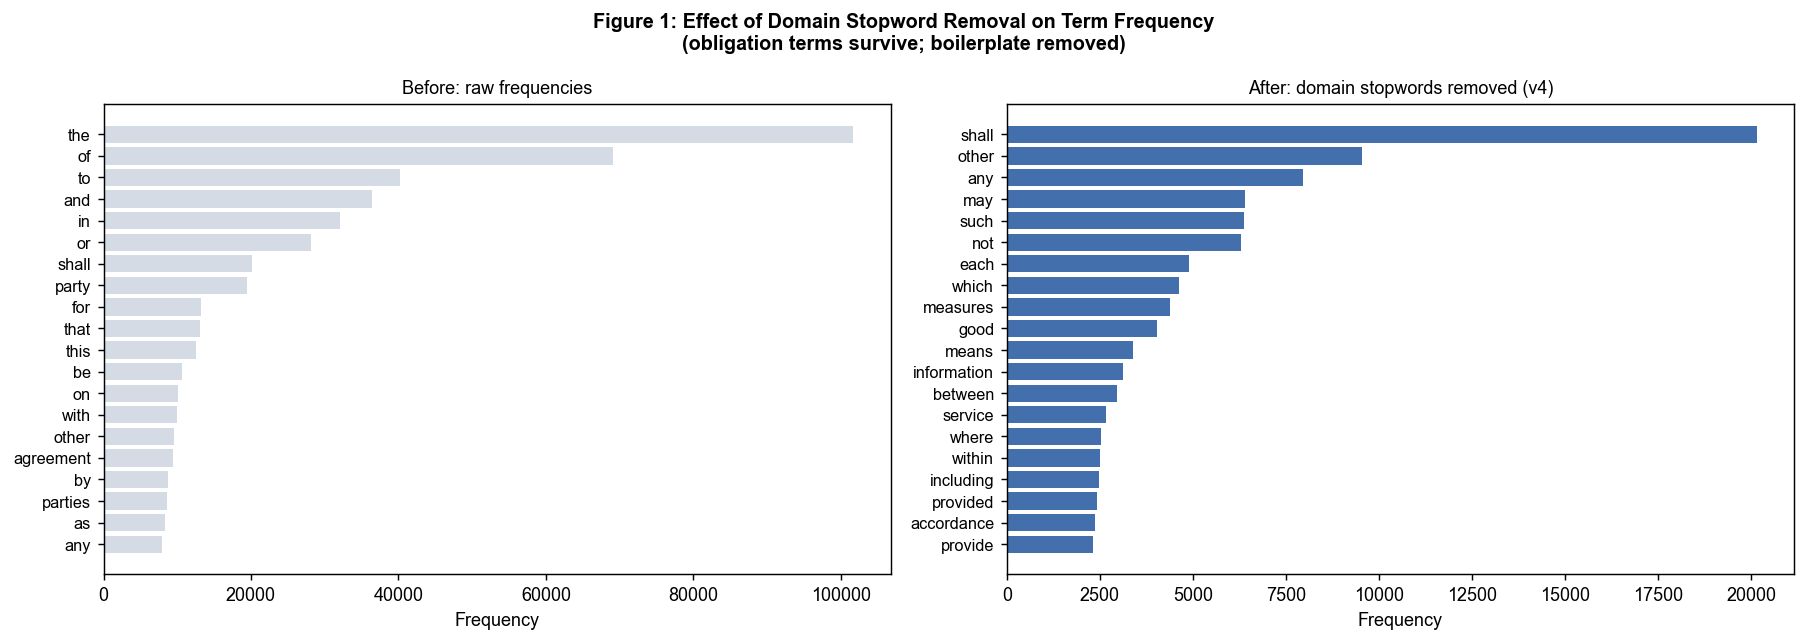

Figure 1 saved.


In [48]:
# ── Figure 1: Preprocessing before/after ─────────────────────────────────────
all_tokens_raw   = [t for tokens in df_articles['article_text'].apply(
    lambda t: preprocess(t, remove_stops=False)) for t in tokens]
all_tokens_clean = [t for tokens in df_articles['tokens'] for t in tokens]

freq_raw   = Counter(all_tokens_raw).most_common(20)
freq_clean = Counter(all_tokens_clean).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 1: Effect of Domain Stopword Removal on Term Frequency\n'
             '(obligation terms survive; boilerplate removed)',
             fontsize=11, fontweight='bold')

for ax, (freq, title, col) in zip(axes, [
    (freq_raw,   'Before: raw frequencies',                    '#D0D7E3'),
    (freq_clean, 'After: domain stopwords removed (v4)',       '#2E5FA3')
]):
    words, counts = zip(*freq)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=col, alpha=0.9)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Frequency')
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig1_preprocessing.png'), bbox_inches='tight')
plt.show()
print("Figure 1 saved.")


---
## Part 10: Obligation Language Scoring (v4)

### Key improvements over v3
**Longest-match-first with semantic priority:**
Matching order: OBLIGATION_MIXED → OBLIGATION_SOFT → OBLIGATION_HARD
This prevents double-counting and correctly handles mixed phrases.

**OBLIGATION_MIXED:** "shall endeavour"-type phrases where a hard grammatical
vehicle carries soft substantive content. Grounded in international legal
drafting conventions — these are best-efforts obligations, not binding ones.
Counted as soft in the final ratio.

**Removed from OBLIGATION_SOFT:** "may" (permissive, not aspirational per
Vienna Convention) and "consider" (procedural instruction).

**Removed from ENFORCEMENT:** "days" (fires on all deadline articles —
too diffuse to carry enforcement signal).

**Added to OBLIGATION_HARD:** phrases from Hofmann et al. enforceability
framework: "shall be entitled to", "shall have the right to", "shall be
subject to".


In [49]:
# ── Obligation dictionaries (v4) ──────────────────────────────────────────────

# MIXED: hard grammatical vehicle + soft substantive content
# Matched FIRST — consumed before SOFT or HARD matching runs.
# Grounding: Vienna Convention drafting guidance; Abbott et al. (2000)
# treat these as nominally binding but substantively aspirational.
OBLIGATION_MIXED = [
    'shall endeavour', 'shall endeavor',
    'shall seek to', 'shall promote',
    'shall encourage', 'shall aim to',
    'shall strive', 'shall facilitate',
    'shall cooperate', 'shall take into account',
    'shall have regard to', 'shall consider',
    'shall work towards', 'shall work toward',
    'shall use best efforts', 'shall make every effort',
]

# SOFT: pure aspiration / best-efforts markers
# "may" and "consider" REMOVED (permissive/procedural — see stopwords docstring)
OBLIGATION_SOFT = [
    'should', 'endeavour', 'endeavor',
    'endeavours', 'endeavors',
    'encourage', 'promotes', 'promoted',
    'best efforts', 'best endeavours',
    'where possible', 'where feasible',
    'to the extent possible', 'to the extent practicable',
    'seek to', 'seeks to',
    'strive', 'strives',
    'aim to', 'aims to',
]

# HARD: binding obligation markers
# Added: "shall be entitled to", "shall have the right to", "shall be subject to"
# (Hofmann et al. enforceability framework grounding)
OBLIGATION_HARD = [
    'shall', 'must',
    'is required', 'are required', 'required to',
    'obliged to', 'obligated to',
    'shall ensure', 'must ensure', 'will ensure',
    'shall be prohibited', 'is prohibited', 'are prohibited',
    'shall not', 'must not',
    'undertakes', 'undertakes to', 'undertake to',
    'commits to', 'commit to', 'commits',
    'binds', 'bound to', 'bound by',
    'shall be entitled to', 'shall have the right to',
    'shall be subject to',
]

# ENFORCEMENT: DS machinery and consequence language
# "days" REMOVED — fires on all deadline articles, too diffuse
ENFORCEMENT = [
    'dispute', 'arbitration', 'arbitral', 'arbitrator',
    'panel', 'tribunal',
    'remedy', 'remedies',
    'sanction', 'sanctions',
    'compensation', 'compensate',
    'retaliation', 'retaliatory',
    'suspension', 'suspended',
    'countermeasure', 'countermeasures',
    'enforce', 'enforcement', 'enforceable',
    'comply', 'compliance', 'non-compliance',
    'violation', 'violate', 'breach',
    'ruling', 'rulings', 'finding', 'findings',
    'appellate', 'appeal',
    'consultations',
    'binding ruling', 'final ruling',
]

# ── Sanity check ───────────────────────────────────────────────────────────────
core_check = ['shall', 'must', 'endeavour', 'arbitration', 'compliance', 'dispute']
missing = [t for t in core_check if t not in LAYER_3_PROTECT]
if missing:
    print(f'\u26a0 Warning: these core terms not in LAYER_3_PROTECT: {missing}')
else:
    print('\u2713 Core dictionary terms confirmed in LAYER_3_PROTECT')

# Check MIXED terms not in HARD or SOFT (they shouldn't be)
mixed_in_hard = [t for t in OBLIGATION_MIXED if t in OBLIGATION_HARD]
mixed_in_soft = [t for t in OBLIGATION_MIXED if t in OBLIGATION_SOFT]
if mixed_in_hard or mixed_in_soft:
    print(f'\u26a0 MIXED terms found in HARD: {mixed_in_hard}')
    print(f'\u26a0 MIXED terms found in SOFT: {mixed_in_soft}')
else:
    print('\u2713 OBLIGATION_MIXED terms do not overlap with HARD or SOFT')

print(f'\nDictionary sizes: MIXED={len(OBLIGATION_MIXED)}, SOFT={len(OBLIGATION_SOFT)}, HARD={len(OBLIGATION_HARD)}, ENF={len(ENFORCEMENT)}')


✓ Core dictionary terms confirmed in LAYER_3_PROTECT
✓ OBLIGATION_MIXED terms do not overlap with HARD or SOFT

Dictionary sizes: MIXED=16, SOFT=20, HARD=27, ENF=36


In [50]:
# ── dict_score_v4: longest-match-first with semantic priority ─────────────────
#
# Algorithm:
# 1. Work on lowercased text copy
# 2. Sort each list longest-first (greedy matching)
# 3. Match MIXED first — replace matched spans with placeholder to prevent
#    re-matching by SOFT or HARD
# 4. Match SOFT on remaining text
# 5. Match HARD on remaining text
# 6. ENFORCEMENT scored independently on original text (no interaction)
#
# Placeholders use unlikely character sequence to avoid false matches.

PLACEHOLDER = '\x00MATCHED\x00'

def _consume(text, term_list):
    """
    Match terms in text (longest first), count hits, replace with placeholder.
    Returns (count, text_with_placeholders).
    """
    terms_sorted = sorted(term_list, key=len, reverse=True)
    count = 0
    for term in terms_sorted:
        hits = text.count(term)
        if hits > 0:
            count += hits
            text = text.replace(term, PLACEHOLDER)
    return count, text

def dict_score_v4(text, mixed_list, soft_list, hard_list, enf_list):
    """
    Score one article with longest-match-first semantic priority.

    Priority: MIXED -> SOFT -> HARD (on progressively consumed text)
    ENFORCEMENT scored independently.

    Returns dict with raw counts and per-1000-word rates.
    """
    n_words = len(text.split())
    if n_words == 0:
        return {
            'mixed_raw': 0, 'soft_raw': 0, 'hard_raw': 0, 'enf_raw': 0,
            'mixed_p1k': 0, 'soft_p1k': 0, 'hard_p1k': 0, 'enf_p1k': 0,
        }

    text_lower = text.lower()

    # Step 1: match MIXED (soft compounds) — consume first
    mixed_raw, text_remaining = _consume(text_lower, mixed_list)

    # Step 2: match SOFT on remaining text
    soft_raw, text_remaining = _consume(text_remaining, soft_list)

    # Step 3: match HARD on remaining text
    hard_raw, _ = _consume(text_remaining, hard_list)

    # Step 4: enforcement scored on original text (independent)
    enf_raw, _ = _consume(text_lower, enf_list)

    def p1k(raw):
        return (raw / n_words * 1000) if n_words > 0 else 0

    return {
        'mixed_raw': mixed_raw, 'soft_raw':  soft_raw,
        'hard_raw':  hard_raw,  'enf_raw':   enf_raw,
        'mixed_p1k': p1k(mixed_raw), 'soft_p1k': p1k(soft_raw),
        'hard_p1k':  p1k(hard_raw),  'enf_p1k':  p1k(enf_raw),
    }

# ── Apply scoring ──────────────────────────────────────────────────────────────
print("Scoring articles...")
scores = df_articles['article_text'].apply(
    lambda t: pd.Series(dict_score_v4(t, OBLIGATION_MIXED, OBLIGATION_SOFT,
                                       OBLIGATION_HARD, ENFORCEMENT))
)
df_articles = pd.concat([df_articles, scores], axis=1)

# oblig_ratio: hard / (soft_total + 1)
# soft_total = soft_raw + mixed_raw (mixed counted as soft in ratio)
df_articles['soft_total'] = df_articles['soft_raw'] + df_articles['mixed_raw']
df_articles['oblig_ratio'] = df_articles['hard_raw'] / (df_articles['soft_total'] + 1)

print(f"Scoring complete.")
print(f"  hard_p1k mean : {df_articles['hard_p1k'].mean():.2f}")
print(f"  soft_p1k mean : {df_articles['soft_p1k'].mean():.2f}")
print(f"  mixed_p1k mean: {df_articles['mixed_p1k'].mean():.2f}")
print(f"  enf_p1k mean  : {df_articles['enf_p1k'].mean():.2f}")
print(f"  oblig_ratio mean: {df_articles['oblig_ratio'].mean():.3f}")


Scoring articles...
Scoring complete.
  hard_p1k mean : 19.79
  soft_p1k mean : 1.06
  mixed_p1k mean: 0.85
  enf_p1k mean  : 7.09
  oblig_ratio mean: 2.213


---
## Part 11: oblig_ratio Distribution Check

Validation step before producing any interpretive figures.

In [51]:
# ── Agreement-level aggregation ───────────────────────────────────────────────
def w_mean(g, val, wt):
    """Length-weighted mean."""
    return (g[val] * g[wt]).sum() / g[wt].sum() if g[wt].sum() > 0 else 0

df_agreement = df_articles.groupby(['pta_id', 'agreement_name', 'year']).apply(
    lambda g: pd.Series({
        'total_words':    g['word_count'].sum(),
        'n_articles':     len(g),
        'n_chapters':     g['chapter_norm'].nunique(),
        'hard_p1k_mean':  w_mean(g, 'hard_p1k',   'word_count'),
        'soft_p1k_mean':  w_mean(g, 'soft_p1k',   'word_count'),
        'mixed_p1k_mean': w_mean(g, 'mixed_p1k',  'word_count'),
        'enf_p1k_mean':   w_mean(g, 'enf_p1k',    'word_count'),
        'oblig_ratio':    w_mean(g, 'oblig_ratio', 'word_count'),
        'hard_total':     g['hard_raw'].sum(),
        'soft_total':     g['soft_total'].sum(),
    })
).reset_index()
df_agreement['year'] = pd.to_numeric(df_agreement['year'], errors='coerce')

# ── oblig_ratio_core: Trade in Goods chapters only ────────────────────────────
# NaN if agreement has no Trade in Goods chapter
tig_articles = df_articles[df_articles['chapter_norm'] == 'Trade in Goods']
tig_agg = tig_articles.groupby('pta_id').apply(
    lambda g: pd.Series({
        'oblig_ratio_core': w_mean(g, 'oblig_ratio', 'word_count'),
        'n_tig_articles': len(g),
    })
).reset_index()

df_agreement = df_agreement.merge(tig_agg, on='pta_id', how='left')
# NaN for agreements without Trade in Goods chapters (already handled by left join)
n_core_nan = df_agreement['oblig_ratio_core'].isna().sum()
print(f"oblig_ratio_core: {df_agreement['oblig_ratio_core'].notna().sum()} agreements have Trade in Goods chapters")
print(f"  NaN (no TiG chapter): {n_core_nan} agreements")

# ── Add asymmetry flags ────────────────────────────────────────────────────────
df_agreement = regression_controls(df_agreement, df_meta)

print(f"\nAgreement-level table: {len(df_agreement)} rows x {len(df_agreement.columns)} cols")
print("\noblig_ratio distribution:")
print(df_agreement['oblig_ratio'].describe().round(3).to_string())


oblig_ratio_core: 53 agreements have Trade in Goods chapters
  NaN (no TiG chapter): 39 agreements

Agreement-level table: 92 rows x 32 cols

oblig_ratio distribution:
count    92.000
mean      3.430
std       1.941
min       0.000
25%       2.378
50%       3.181
75%       4.349
max      13.859


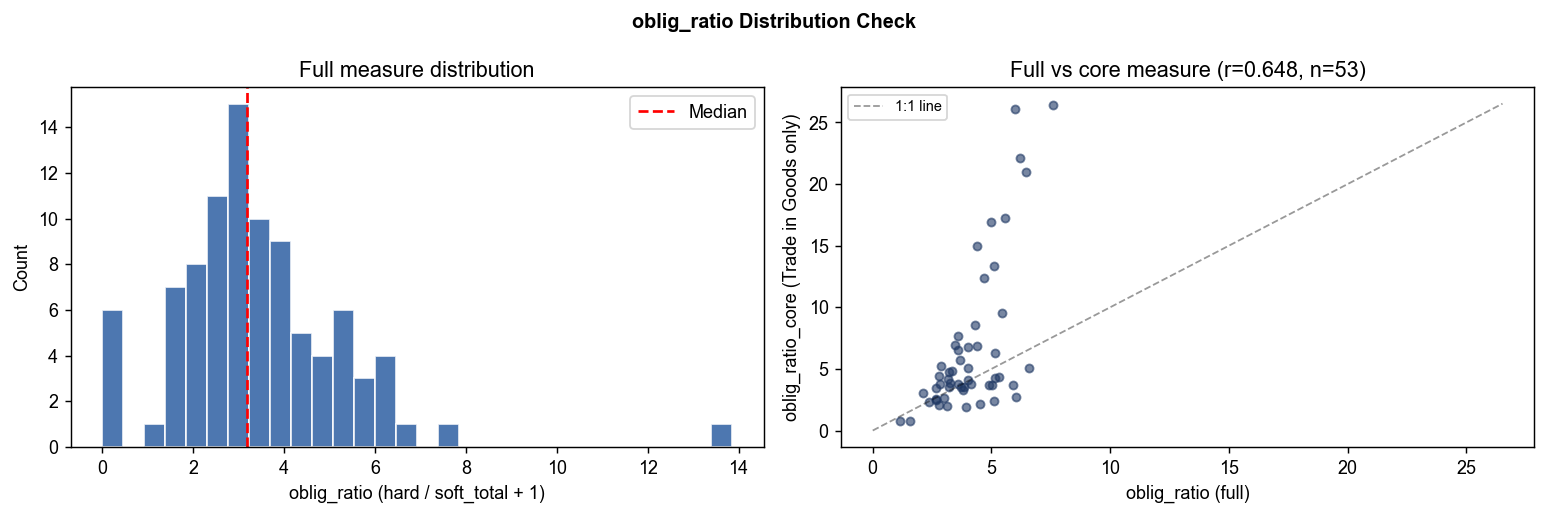


✓ DS chapter mean oblig_ratio: 3.485
  Cooperation chapter mean   : 1.108
  Expected: DS > Cooperation. PASS


In [52]:
# ── Distribution sanity checks ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('oblig_ratio Distribution Check', fontsize=11, fontweight='bold')

# Histogram
ax = axes[0]
ax.hist(df_agreement['oblig_ratio'].dropna(), bins=30, color='#2E5FA3', alpha=0.85, edgecolor='white')
ax.axvline(df_agreement['oblig_ratio'].median(), color='red', linestyle='--', label='Median')
ax.set_xlabel('oblig_ratio (hard / soft_total + 1)')
ax.set_ylabel('Count')
ax.set_title('Full measure distribution')
ax.legend()

# Core vs full scatter
ax = axes[1]
merged_check = df_agreement.dropna(subset=['oblig_ratio', 'oblig_ratio_core'])
ax.scatter(merged_check['oblig_ratio'], merged_check['oblig_ratio_core'],
           alpha=0.6, s=20, color='#1F3864')
lim = max(merged_check['oblig_ratio'].max(), merged_check['oblig_ratio_core'].max()) + 0.1
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, alpha=0.4, label='1:1 line')
r_val = merged_check[['oblig_ratio', 'oblig_ratio_core']].corr().iloc[0, 1]
ax.set_xlabel('oblig_ratio (full)')
ax.set_ylabel('oblig_ratio_core (Trade in Goods only)')
ax.set_title(f'Full vs core measure (r={r_val:.3f}, n={len(merged_check)})')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_distribution_check.png'), bbox_inches='tight')
plt.show()

# ── Validation assertion ───────────────────────────────────────────────────────
ds_chapters = df_articles[df_articles['chapter_norm'] == 'Dispute Settlement']
coop_chapters = df_articles[df_articles['chapter_norm'] == 'Cooperation & Development']
if len(ds_chapters) > 0 and len(coop_chapters) > 0:
    ds_ratio   = ds_chapters['oblig_ratio'].mean()
    coop_ratio = coop_chapters['oblig_ratio'].mean()
    flag = '\u2713' if ds_ratio > coop_ratio else '\u26a0'
    print(f"\n{flag} DS chapter mean oblig_ratio: {ds_ratio:.3f}")
    print(f"  Cooperation chapter mean   : {coop_ratio:.3f}")
    print(f"  Expected: DS > Cooperation. {'PASS' if ds_ratio > coop_ratio else 'FAIL — check normalization'}")


---
## Part 12: TF-IDF Bigram Validation (Figure 2)

Data-driven validation: do agreements classified as high-ratio by the dictionary also use different vocabulary according to a fully independent method?

In [53]:
# ── Phrase-aware preprocessing for n-gram analysis ───────────────────────────
PROTECTED_PHRASES = sorted(
    [t for t in LAYER_3_PROTECT if ' ' in t], key=len, reverse=True
)

def protect_phrases(text):
    t = text.lower()
    for phrase in PROTECTED_PHRASES:
        t = t.replace(phrase, phrase.replace(' ', '_'))
    return t

def preprocess_ngram(text):
    protected = protect_phrases(text)
    tokens = protected.split()
    tokens = [re.sub(r'\W+', '', t) for t in tokens]
    tokens = [t for t in tokens if len(t) > 1]
    tokens = [t for t in tokens if t not in TRADE_STOPWORDS]
    return tokens

df_articles['tokens_phrase'] = df_articles['article_text'].apply(preprocess_ngram)

def get_ngrams(tokens, n):
    return ['_'.join(g) for g in nltk_ngrams(tokens, n)]

df_articles['bigrams'] = df_articles['tokens_phrase'].apply(lambda t: get_ngrams(t, 2))
print("Phrase-aware bigrams computed.")


Phrase-aware bigrams computed.


In [54]:
# ── TF-IDF: top vs bottom oblig_ratio quartile ────────────────────────────────
pta_bigram_docs = (
    df_articles.groupby('pta_id')['bigrams']
    .apply(lambda lists: ' '.join(bg for lst in lists for bg in lst))
    .reset_index()
    .rename(columns={'bigrams': 'bigram_doc'})
)
pta_bigram_docs = pta_bigram_docs.merge(
    df_agreement[['pta_id', 'agreement_name', 'oblig_ratio']], on='pta_id'
)

vec = TfidfVectorizer(max_features=600, min_df=3)
tfidf_matrix = vec.fit_transform(pta_bigram_docs['bigram_doc'])
feat = vec.get_feature_names_out()

q75 = pta_bigram_docs['oblig_ratio'].quantile(0.75)
q25 = pta_bigram_docs['oblig_ratio'].quantile(0.25)
mask_top = (pta_bigram_docs['oblig_ratio'] >= q75).values
mask_bot = (pta_bigram_docs['oblig_ratio'] <= q25).values

mean_top = tfidf_matrix[mask_top].mean(axis=0).A1
mean_bot = tfidf_matrix[mask_bot].mean(axis=0).A1

diff_deep     = mean_top - mean_bot
top20_deep    = diff_deep.argsort()[::-1][:20]
deep_labels   = [feat[i].replace('_', ' ') for i in top20_deep]
deep_scores   = diff_deep[top20_deep]

diff_shallow   = mean_bot - mean_top
top20_shallow  = diff_shallow.argsort()[::-1][:20]
shallow_labels = [feat[i].replace('_', ' ') for i in top20_shallow]
shallow_scores = diff_shallow[top20_shallow]

print(f"High-ratio bigrams (top quartile \u2265 {q75:.2f}, n={mask_top.sum()}):  {deep_labels[:5]}")
print(f"Low-ratio bigrams  (bot quartile \u2264 {q25:.2f}, n={mask_bot.sum()}):  {shallow_labels[:5]}")


High-ratio bigrams (top quartile ≥ 4.35, n=23):  ['each shall', 'joint committee', 'association council', 'originating good', 'charge shall']
Low-ratio bigrams  (bot quartile ≤ 2.38, n=23):  ['third countries', 'contracting shall', 'other contracting', 'third country', 'quantitative restrictions']


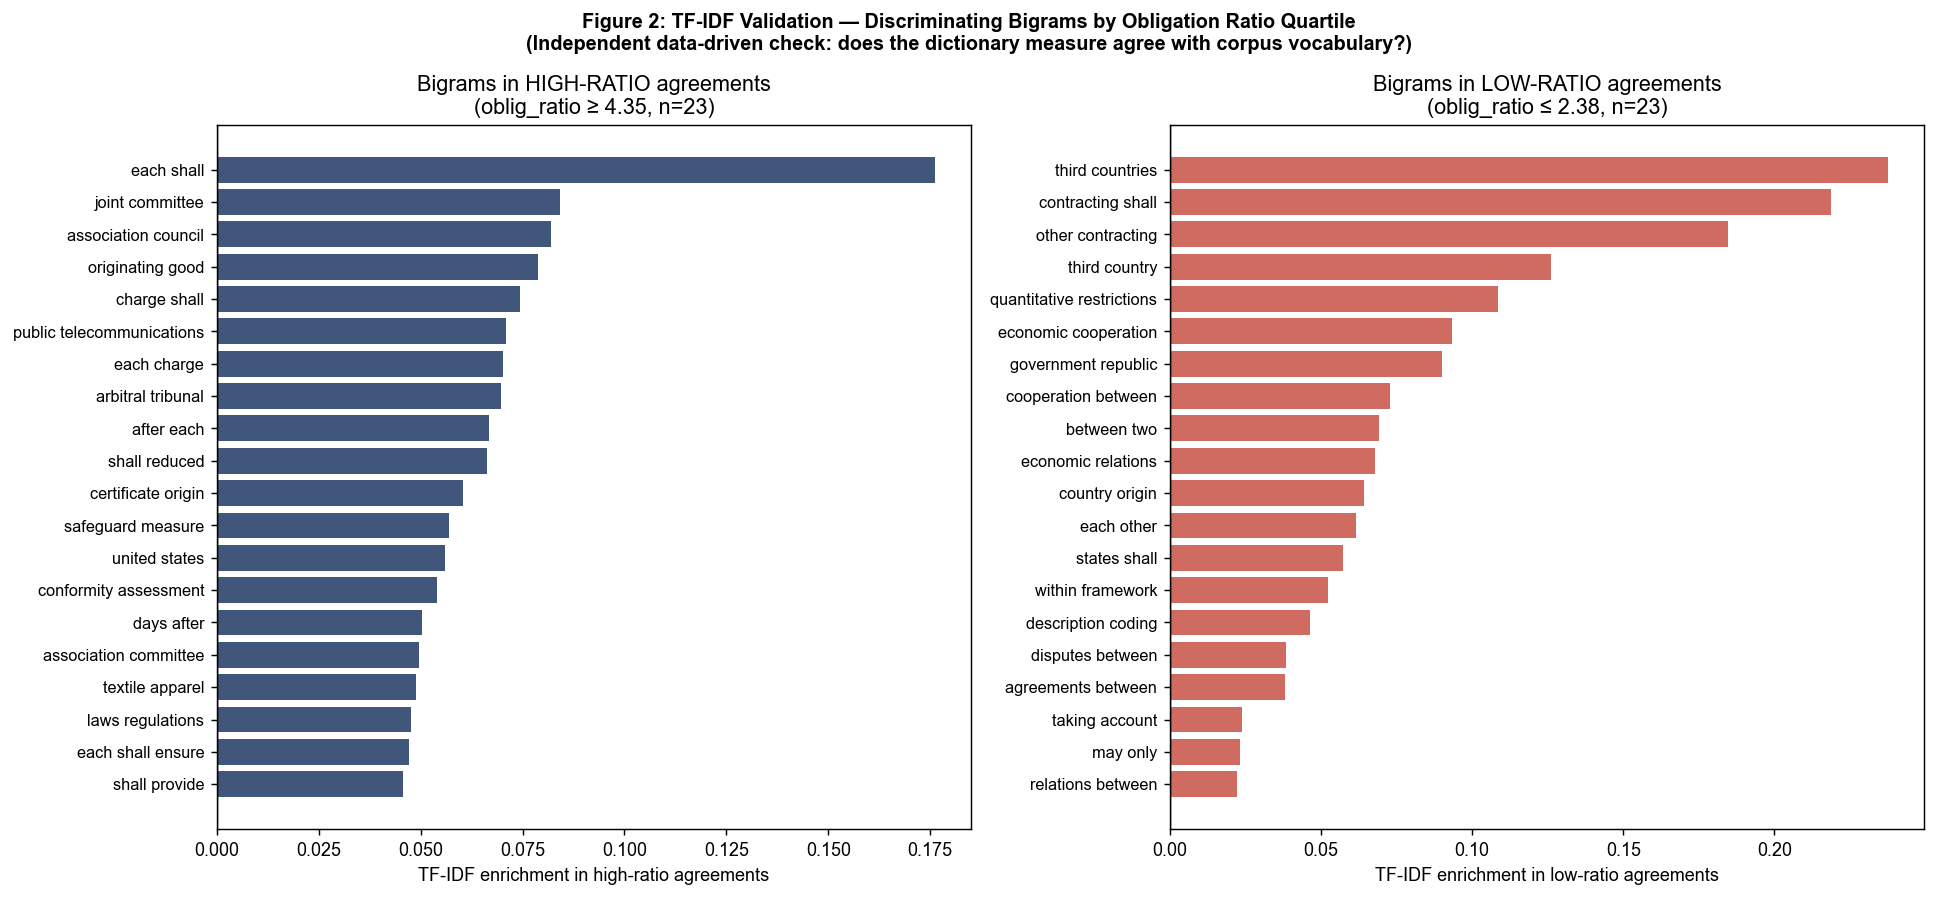

Figure 2 saved.


In [55]:
# ── Figure 2: Discriminating bigrams ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle(
    'Figure 2: TF-IDF Validation — Discriminating Bigrams by Obligation Ratio Quartile\n'
    '(Independent data-driven check: does the dictionary measure agree with corpus vocabulary?)',
    fontsize=11, fontweight='bold'
)

ax1.barh(deep_labels[::-1], deep_scores[::-1], color='#1F3864', alpha=0.85)
ax1.set_xlabel('TF-IDF enrichment in high-ratio agreements')
ax1.set_title(f'Bigrams in HIGH-RATIO agreements\n(oblig_ratio \u2265 {q75:.2f}, n={mask_top.sum()})')
ax1.tick_params(axis='y', labelsize=9)
ax1.axvline(0, color='black', linewidth=0.8)

ax2.barh(shallow_labels[::-1], shallow_scores[::-1], color='#C0392B', alpha=0.75)
ax2.set_xlabel('TF-IDF enrichment in low-ratio agreements')
ax2.set_title(f'Bigrams in LOW-RATIO agreements\n(oblig_ratio \u2264 {q25:.2f}, n={mask_bot.sum()})')
ax2.tick_params(axis='y', labelsize=9)
ax2.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig2_tfidf_validation.png'), bbox_inches='tight')
plt.show()
print("Figure 2 saved.")


---
## Part 13: Figure 3 — Obligation Hardness by Chapter Type

Face validity check. Expected ordering: Dispute Settlement > Trade in Goods > Cooperation > Preamble.

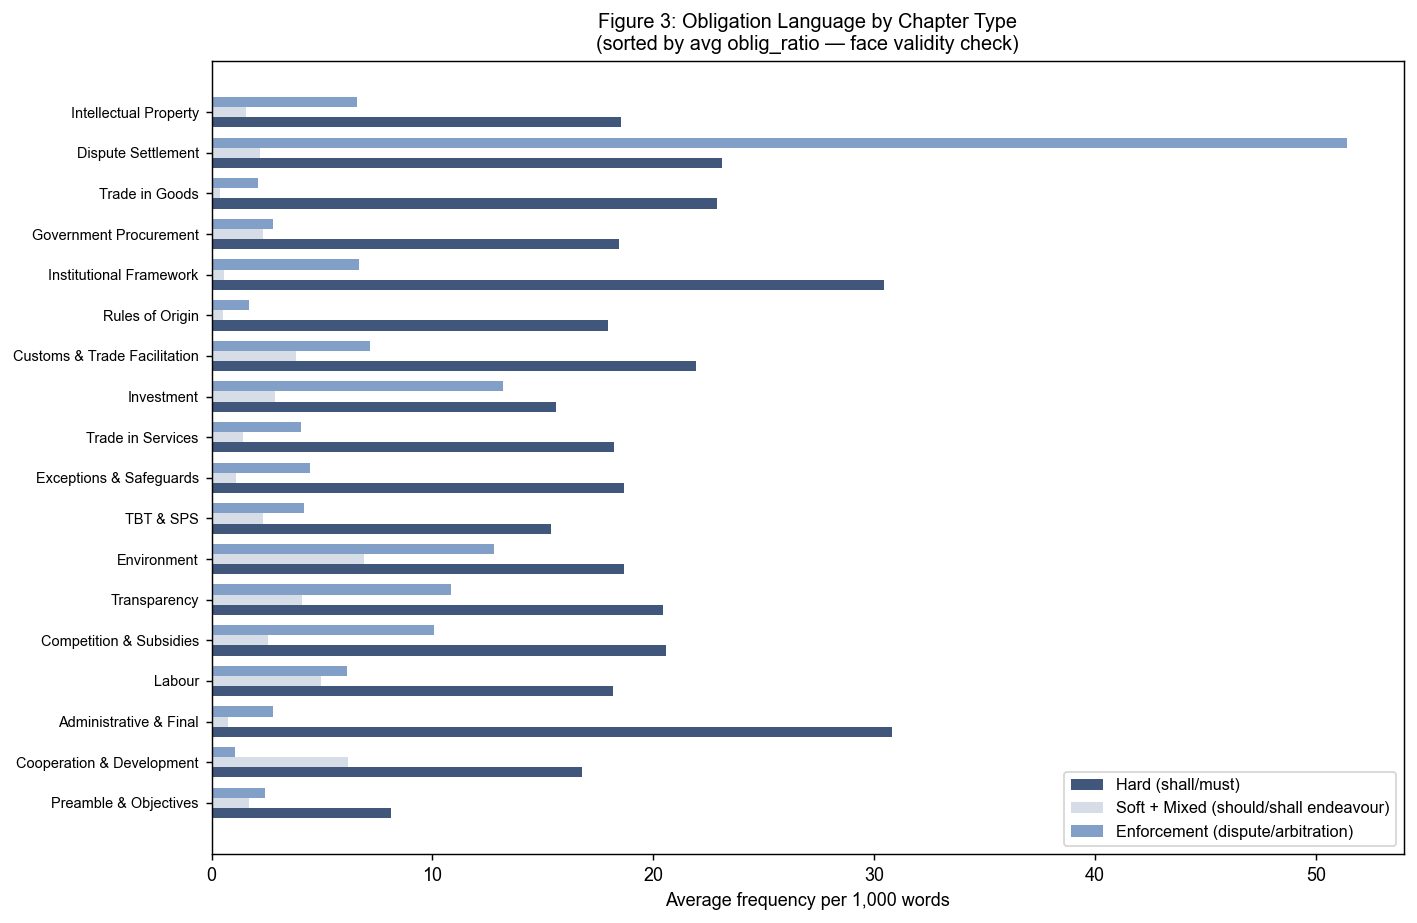

Figure 3 saved.

✓ Face validity: DS ratio=3.485  Coop ratio=1.108


In [56]:
chapter_stats = df_articles.groupby('chapter_norm').agg(
    n_articles      = ('article_text', 'count'),
    avg_hard_p1k    = ('hard_p1k',    'mean'),
    avg_soft_p1k    = ('soft_p1k',    'mean'),
    avg_mixed_p1k   = ('mixed_p1k',   'mean'),
    avg_enf_p1k     = ('enf_p1k',     'mean'),
    avg_oblig_ratio = ('oblig_ratio', 'mean'),
    total_words     = ('word_count',  'sum'),
).reset_index()

# Keep chapters with at least 3 articles; exclude 'Other' catch-all
chapter_stats = chapter_stats[
    (chapter_stats['n_articles'] >= 3) &
    (~chapter_stats['chapter_norm'].str.startswith('Other'))
].sort_values('avg_oblig_ratio', ascending=True)

fig, ax = plt.subplots(figsize=(11, max(6, len(chapter_stats) * 0.4)))

short_ch = [str(c)[:40] for c in chapter_stats['chapter_norm']]
width = 0.25
x     = range(len(chapter_stats))

ax.barh([i - width for i in x], chapter_stats['avg_hard_p1k'],
        height=width, label='Hard (shall/must)', color='#1F3864', alpha=0.85)
ax.barh([i         for i in x], chapter_stats['avg_soft_p1k'] + chapter_stats['avg_mixed_p1k'],
        height=width, label='Soft + Mixed (should/shall endeavour)', color='#D0D7E3', alpha=0.85)
ax.barh([i + width for i in x], chapter_stats['avg_enf_p1k'],
        height=width, label='Enforcement (dispute/arbitration)', color='#2E5FA3', alpha=0.6)

ax.set_yticks(list(x))
ax.set_yticklabels(short_ch, fontsize=8)
ax.set_xlabel('Average frequency per 1,000 words')
ax.set_title('Figure 3: Obligation Language by Chapter Type\n'
             '(sorted by avg oblig_ratio — face validity check)', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig3_chapter_obligation.png'), bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

# ── Face validity check ────────────────────────────────────────────────────────
ds_row   = chapter_stats[chapter_stats['chapter_norm'] == 'Dispute Settlement']
coop_row = chapter_stats[chapter_stats['chapter_norm'] == 'Cooperation & Development']
if len(ds_row) > 0 and len(coop_row) > 0:
    flag = '\u2713' if ds_row['avg_oblig_ratio'].values[0] > coop_row['avg_oblig_ratio'].values[0] else '\u26a0'
    print(f"\n{flag} Face validity: DS ratio={ds_row['avg_oblig_ratio'].values[0]:.3f}  Coop ratio={coop_row['avg_oblig_ratio'].values[0]:.3f}")


### Figure 3b: Top 5 chapters per metric (raw chapter titles)

Three-panel breakdown showing which specific chapter headings score highest on each obligation dimension. Uses raw `chapter_name` (not the normalized taxonomy) so individual chapter titles appear as written in the original treaty texts. The enforcement panel is the key face-validity check: dispute settlement chapters should dominate.

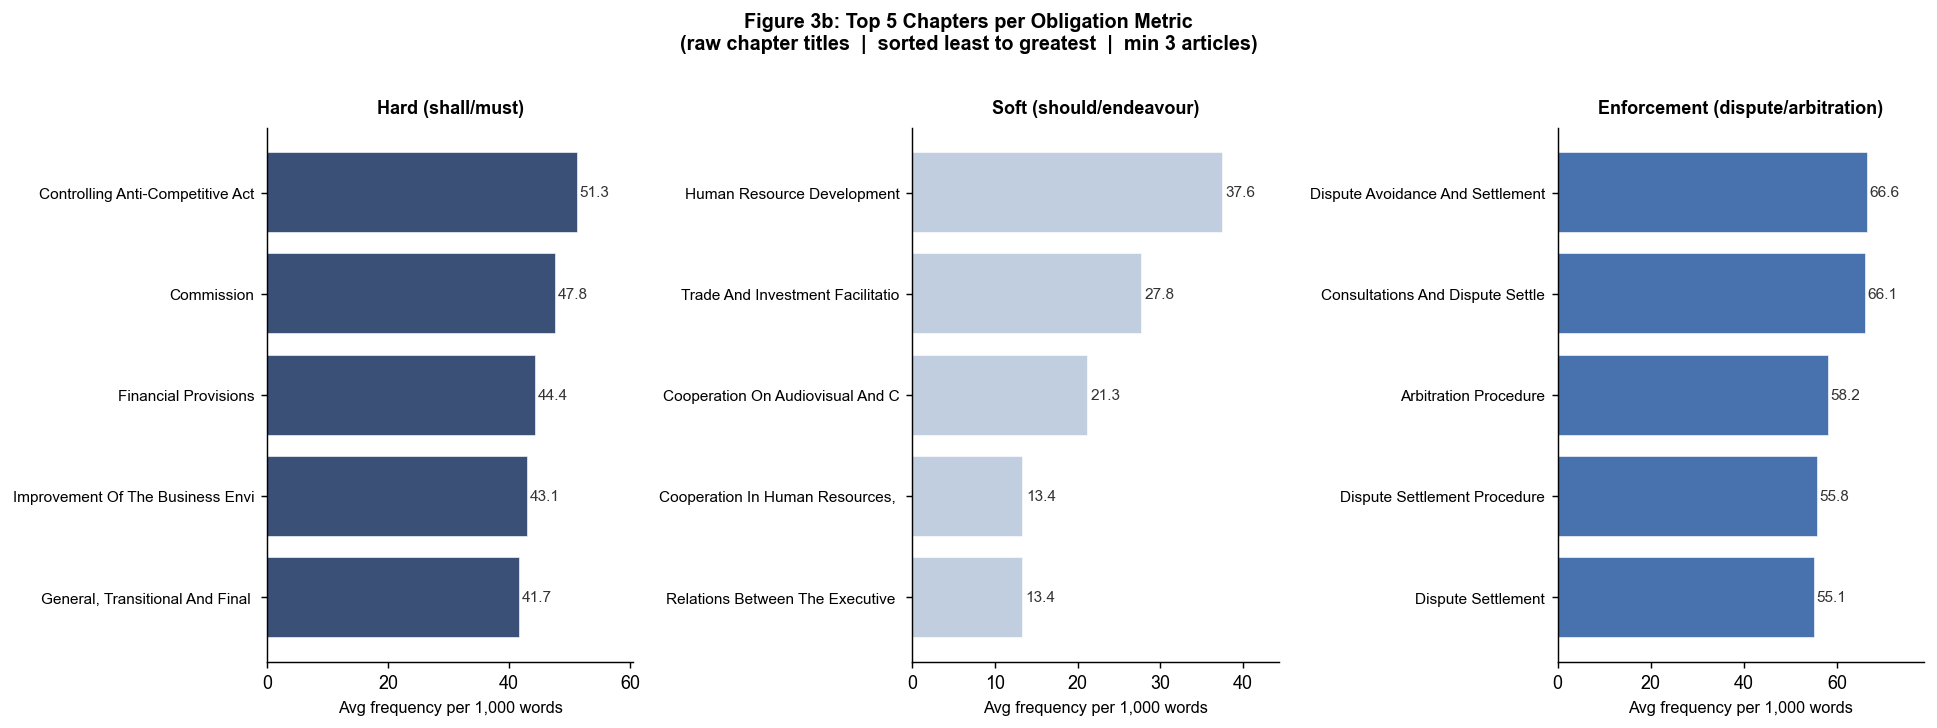

Figure 3b saved.

Top 5 — HARD:
                              chapter_name   avg_p1k  n_articles
General, Transitional And Final Provisions 41.733238          19
   Improvement Of The Business Environment 43.055715           3
                      Financial Provisions 44.383388          11
                                Commission 47.828651           3
   Controlling Anti-Competitive Activities 51.331540           3

Top 5 — SOFT:
                                                                                 chapter_name   avg_p1k  n_articles
Relations Between The Executive Secretariat And The Specialised Institutions Of The Community 13.357925           3
                     Cooperation In Human Resources, Information, Social And Cultural Affairs 13.433564           7
               Cooperation On Audiovisual And Cultural Matters, Information And Communication 21.317829           5
                                                            Trade And Investment Facilitation 27.77

In [57]:
# Figure 3b: Top 5 chapters per metric — raw chapter names
TOP_N = 5
MIN_ARTICLES = 3

# Aggregate on raw chapter_name (not normalized) for specific titles
chapter_raw = df_articles.groupby('chapter_name').agg(
    n_articles    = ('article_text', 'count'),
    avg_hard_p1k  = ('hard_p1k',    'mean'),
    avg_soft_p1k  = ('soft_p1k',    'mean'),
    avg_mixed_p1k = ('mixed_p1k',   'mean'),
    avg_enf_p1k   = ('enf_p1k',     'mean'),
).reset_index()

chapter_raw['avg_softmixed_p1k'] = (chapter_raw['avg_soft_p1k']
                                    + chapter_raw['avg_mixed_p1k'])
chapter_raw = chapter_raw[chapter_raw['n_articles'] >= MIN_ARTICLES].copy()
chapter_raw['label'] = chapter_raw['chapter_name'].str.title().str[:32]

def top_n_asc(df, metric, n=TOP_N):
    return (df.nlargest(n, metric)
              .sort_values(metric, ascending=True)
              .reset_index(drop=True))

top_hard = top_n_asc(chapter_raw, 'avg_hard_p1k')
top_soft = top_n_asc(chapter_raw, 'avg_softmixed_p1k')
top_enf  = top_n_asc(chapter_raw, 'avg_enf_p1k')

DARK_BLUE  = '#1F3864'
LIGHT_BLUE = '#B8C8DC'
MID_BLUE   = '#2E5FA3'

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
fig.suptitle(
    'Figure 3b: Top 5 Chapters per Obligation Metric\n'
    '(raw chapter titles  |  sorted least to greatest  |  min 3 articles)',
    fontsize=11, fontweight='bold', y=1.01
)

panels = [
    (axes[0], top_hard, 'avg_hard_p1k',      DARK_BLUE,  'Hard (shall/must)'),
    (axes[1], top_soft, 'avg_softmixed_p1k',  LIGHT_BLUE, 'Soft (should/endeavour)'),
    (axes[2], top_enf,  'avg_enf_p1k',        MID_BLUE,   'Enforcement (dispute/arbitration)'),
]

for ax, df, metric, color, title in panels:
    bars = ax.barh(df['label'], df[metric], color=color, alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, df[metric]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}', va='center', ha='left', fontsize=8.5, color='#333333')
    ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel('Avg frequency per 1,000 words', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=8.5)
    ax.margins(x=0.18)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig3b_top5_chapters.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3b saved.')

for lbl, df, metric in [
    ('HARD',        top_hard, 'avg_hard_p1k'),
    ('SOFT',        top_soft, 'avg_softmixed_p1k'),
    ('ENFORCEMENT', top_enf,  'avg_enf_p1k'),
]:
    print(f'\nTop {TOP_N} — {lbl}:')
    print(df[['chapter_name', metric, 'n_articles']]
          .rename(columns={metric: 'avg_p1k'}).to_string(index=False))


---
## Part 14: Figure 4 — Obligation Hardness Over Time

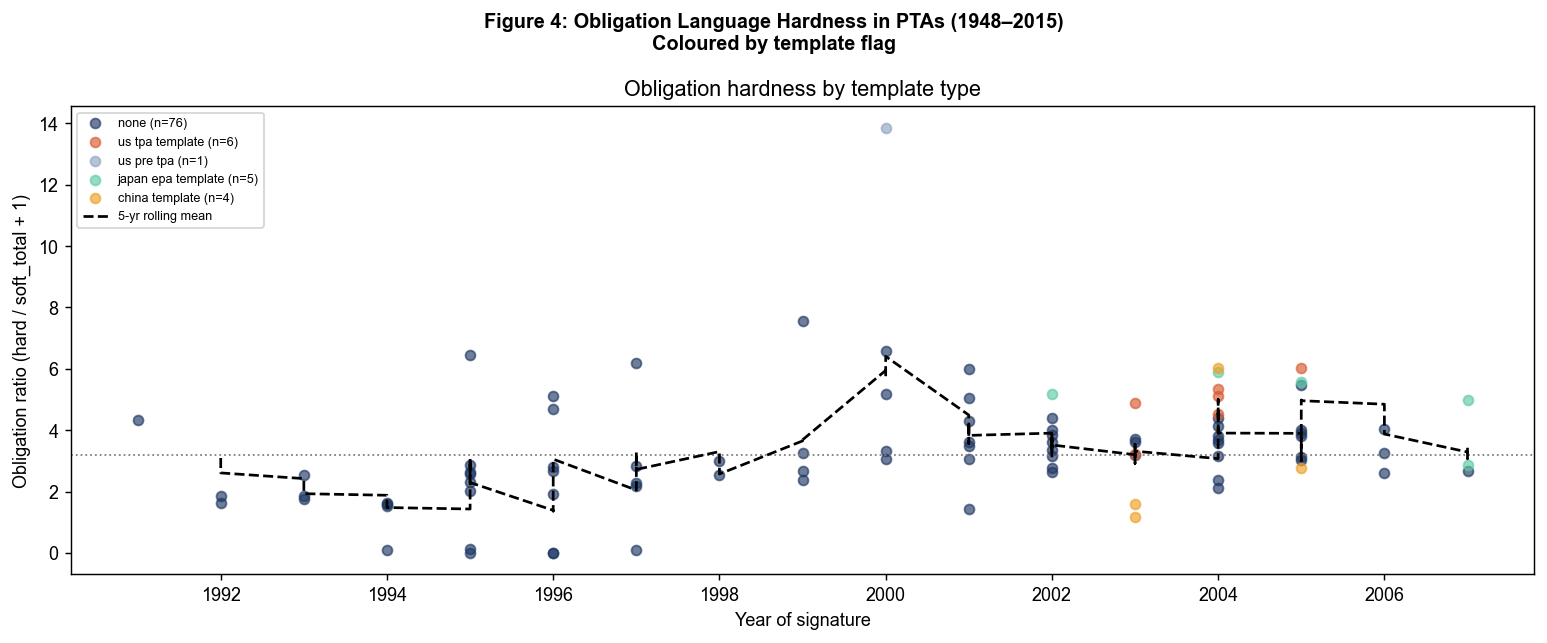

Figure 4 saved.


In [58]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Figure 4: Obligation Language Hardness in PTAs (1948\u20132015)\n'
             'Coloured by template flag', fontsize=11, fontweight='bold')

df_time = df_agreement.dropna(subset=['year', 'oblig_ratio']).copy()

template_colors = {
    'none':               '#1F3864',
    'us_tpa_template':    '#D85A30',
    'eu_template':        '#2E5FA3',
    'us_pre_tpa':         '#8FA3BF',
    'japan_epa_template': '#5DCAA5',
    'china_template':     '#EF9F27',
}
for flag, color in template_colors.items():
    mask = df_time['template_flag'] == flag
    if mask.sum() > 0:
        ax.scatter(df_time.loc[mask, 'year'], df_time.loc[mask, 'oblig_ratio'],
                   color=color, alpha=0.65, s=30, zorder=2,
                   label=f"{flag.replace('_',' ')} (n={mask.sum()})")

if len(df_time) >= 5:
    trend = (df_time.sort_values('year').set_index('year')['oblig_ratio']
             .rolling(window=5, min_periods=2).mean())
    ax.plot(trend.index, trend.values, color='black', linewidth=1.5,
            linestyle='--', label='5-yr rolling mean', zorder=3)

ax.set_xlabel('Year of signature')
ax.set_ylabel('Obligation ratio (hard / soft_total + 1)')
ax.set_title('Obligation hardness by template type')
ax.legend(fontsize=7, loc='upper left')
ax.axhline(df_time['oblig_ratio'].median(), color='grey', linestyle=':', linewidth=1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig4_hardness_over_time.png'), bbox_inches='tight')
plt.show()
print("Figure 4 saved.")


---
## Part 15: Figure 5 — Hofmann et al. External Validation

Merge Hofmann et al. (2017) Horizontal Depth database on wto_rta_id.
Hofmann et al. code each of 52 policy areas as legally enforceable or not
across 279 PTAs. We correlate our continuous oblig_ratio against their
enforceable provision count.

**Conceptual note:** Hofmann et al. measure whether provisions are *present
and formally enforceable* (binary, per policy area). Our measure captures
*how binding the language is* within whatever provisions exist (continuous).
These are related but distinct constructs — a moderate correlation confirms
overlap without redundancy. A very high correlation (r > 0.8) would suggest
redundancy; near zero would suggest construct invalidity.

**Merge key:** wto_rta_id (already in df_meta from ToTA XML, present in
Hofmann et al. dataset).


In [64]:
# ── Load Hofmann et al. (2017) Horizontal Depth database ─────────────────────
# Source: World Bank — http://data.worldbank.org/data-catalog/deep-trade-agreements
# File has 4 sheets: WTO+AC, WTO+LE, WTO-X AC, WTO-X LE
# We use the two LE (legally enforceable) sheets.
# Coding: 0 = absent/not enforceable, 1 = present but DS excluded, 2 = fully enforceable
# Merge key: RTAID → wto_rta_id in df_meta

HOFMANN_PATH = 'DTA 1.0 - Horizontal Content (v2).xlsx'

if os.path.exists(HOFMANN_PATH):

    # ── Load WTO+ LE sheet (core WTO-mandate provisions) ─────────────────────
    df_wto_le = pd.read_excel(HOFMANN_PATH, sheet_name='WTO+ LE')
    id_cols   = ['RTAID', 'WBID', 'Agreement']
    prov_wto  = [c for c in df_wto_le.columns if c not in id_cols]

    # ── Load WTO-X LE sheet (provisions outside WTO mandate) ─────────────────
    df_wtox_le = pd.read_excel(HOFMANN_PATH, sheet_name='WTO-X LE')
    prov_wtox  = [c for c in df_wtox_le.columns if c not in id_cols]

    # ── Compute three scores per agreement ────────────────────────────────────
    # Score A: any legal force — value >= 1 (present, regardless of DS exclusion)
    # Captures hard obligation language whether or not DS machinery was included.
    # This is closest to what oblig_ratio measures — language hardness at provision level.
    df_wto_le['wto_plus_present']  = (df_wto_le[prov_wto]  >= 1).sum(axis=1)
    df_wtox_le['wtox_present']     = (df_wtox_le[prov_wtox] >= 1).sum(axis=1)

    # Score B: fully enforceable only — value == 2 (present + DS not excluded)
    # Strictest reading of enforceability; may undercount hard-language agreements
    # where DS was formally excluded at agreement level.
    df_wto_le['wto_plus_enf']  = (df_wto_le[prov_wto]  == 2).sum(axis=1)
    df_wtox_le['wtox_enf']     = (df_wtox_le[prov_wtox] == 2).sum(axis=1)

    # Score C: weighted — value 1 counts as 0.5, value 2 counts as 1.0
    # Partial credit for provisions with hard language but excluded DS.
    # Predicted to correlate highest with oblig_ratio.
    df_wto_le['wto_plus_weighted'] = (
        (df_wto_le[prov_wto] == 1).sum(axis=1) * 0.5 +
        (df_wto_le[prov_wto] == 2).sum(axis=1) * 1.0
    )
    df_wtox_le['wtox_weighted'] = (
        (df_wtox_le[prov_wtox] == 1).sum(axis=1) * 0.5 +
        (df_wtox_le[prov_wtox] == 2).sum(axis=1) * 1.0
    )

    # ── Merge WTO+ and WTO-X sheets ───────────────────────────────────────────
    df_hofmann = df_wto_le[['RTAID', 'Agreement',
                             'wto_plus_present', 'wto_plus_enf',
                             'wto_plus_weighted']].merge(
        df_wtox_le[['RTAID', 'wtox_present', 'wtox_enf', 'wtox_weighted']],
        on='RTAID', how='outer'
    ).fillna(0)

    # Total scores across WTO+ and WTO-X
    df_hofmann['enf_present']  = df_hofmann['wto_plus_present']  + df_hofmann['wtox_present']
    df_hofmann['enf_strict']   = df_hofmann['wto_plus_enf']      + df_hofmann['wtox_enf']
    df_hofmann['enf_weighted'] = df_hofmann['wto_plus_weighted']  + df_hofmann['wtox_weighted']

    df_hofmann = df_hofmann.rename(columns={'RTAID': 'wto_rta_id'})

    print(f"Hofmann data loaded: {len(df_hofmann)} agreements")
    print(f"\nScore ranges:")
    for col in ['enf_present', 'enf_strict', 'enf_weighted']:
        print(f"  {col:<18}: min={df_hofmann[col].min():.1f}  "
              f"max={df_hofmann[col].max():.1f}  "
              f"mean={df_hofmann[col].mean():.1f}")
    print(f"\nSample:")
    print(df_hofmann[['wto_rta_id', 'Agreement',
                       'enf_present', 'enf_strict', 'enf_weighted']].head(6).to_string(index=False))

else:
    print(f"⚠ Hofmann data not found at '{HOFMANN_PATH}'.")
    print("  Place the .xlsx file in your working directory.")
    df_hofmann = None

Hofmann data loaded: 391 agreements

Score ranges:
  enf_present       : min=0.0  max=46.0  mean=14.0
  enf_strict        : min=0.0  max=37.0  mean=11.4
  enf_weighted      : min=0.0  max=37.5  mean=12.7

Sample:
wto_rta_id                                          Agreement  enf_present  enf_strict  enf_weighted
         1                                   Japan - Thailand           13          13          13.0
         2                                    Egypt - Türkiye            8           8           8.0
         3                                      Chile - Japan           17          14          15.5
         4 Central European Free Trade Agreement (CEFTA) 2006           16          16          16.0
         5                                       EFTA - Egypt           14          14          14.0
         6                                EC (27) Enlargement           36          35          35.5


Validation sample: 89 agreements (inner join on wto_rta_id)
  (89/92 = 97% of agreements matched)

Correlations with oblig_ratio:
  Any legal force (≥1)               : r = +0.383  (p = 0.0002) *
  Fully enforceable (=2)             : r = +0.351  (p = 0.0007) *
  Weighted (1→0.5, 2→1.0)            : r = +0.380  (p = 0.0002) *

Best correlation: Any legal force (≥1) — used for Figure 5


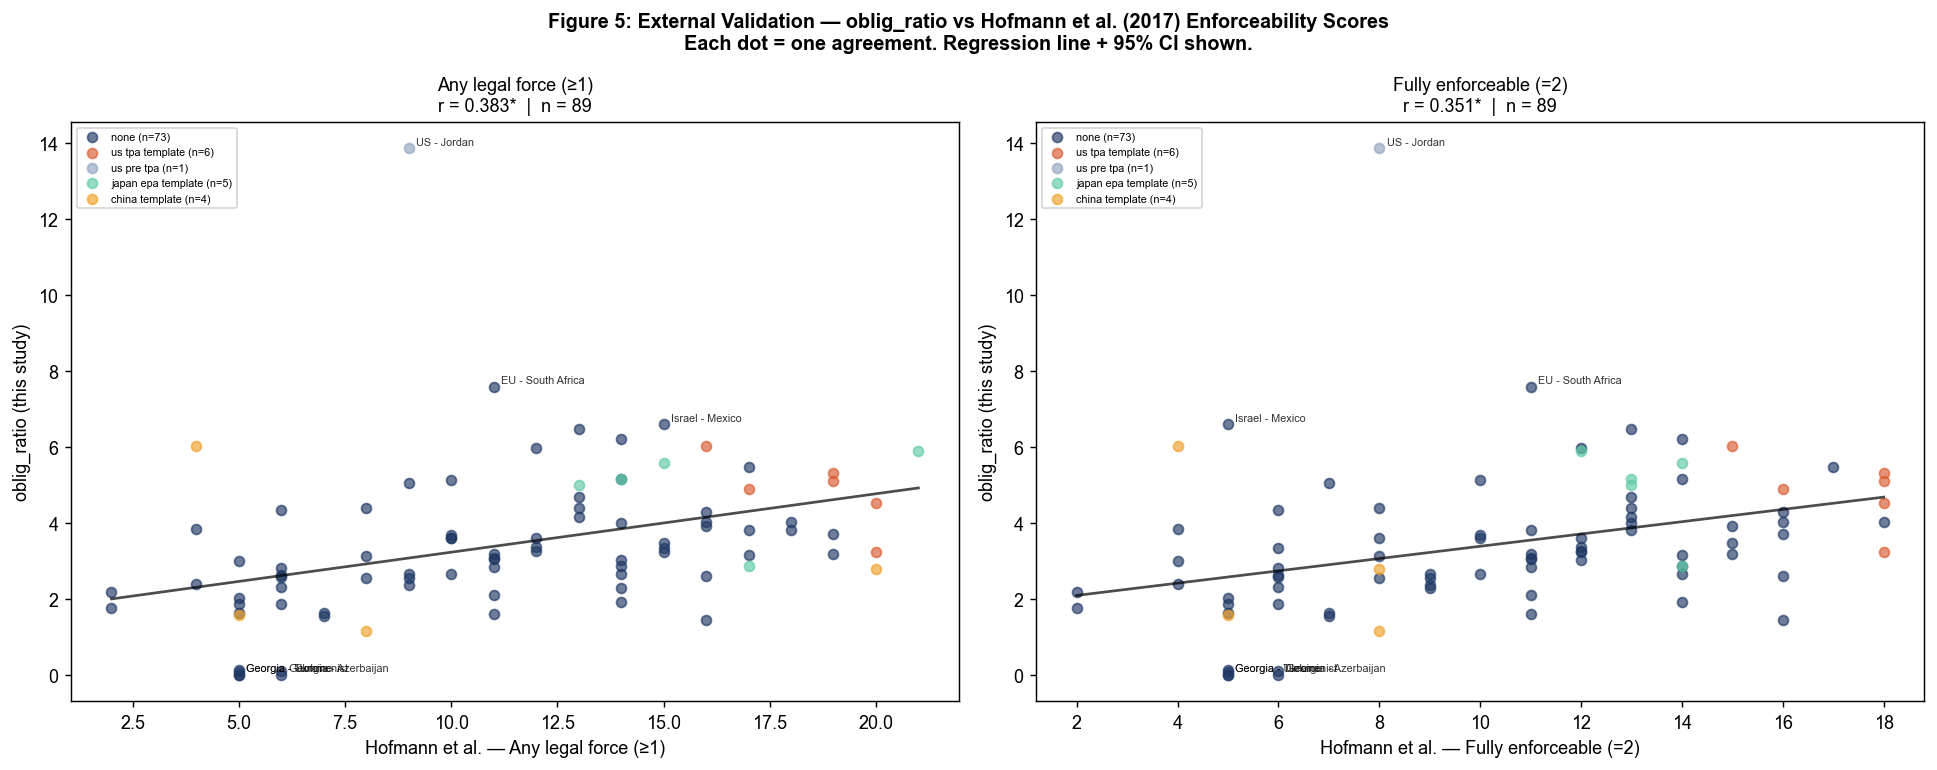

Figure 5 saved.

Interpretation:
  Weighted score r = +0.380 vs strict enforceability r = +0.351
  ✓ Weighted > strict: oblig_ratio captures language hardness at provision
    level, not just formal DS architecture — consistent with theoretical framing.


In [65]:
# ── Merge Hofmann scores into agreement-level table ───────────────────────────
if df_hofmann is not None:

    df_val = (
        df_agreement
        .merge(df_meta[['pta_id', 'wto_rta_id']], on='pta_id', how='left')
        .merge(df_hofmann[['wto_rta_id', 'enf_present', 'enf_strict', 'enf_weighted']],
               on='wto_rta_id', how='inner')
        .dropna(subset=['oblig_ratio', 'enf_present'])
    )

    print(f"Validation sample: {len(df_val)} agreements (inner join on wto_rta_id)")
    n_total = len(df_agreement)
    print(f"  ({len(df_val)}/{n_total} = {100*len(df_val)/n_total:.0f}% of agreements matched)")

    # ── Compute three correlations ────────────────────────────────────────────
    score_cols = {
        'enf_present':  'Any legal force (≥1)',
        'enf_strict':   'Fully enforceable (=2)',
        'enf_weighted': 'Weighted (1→0.5, 2→1.0)',
    }
    correlations = {}
    print("\nCorrelations with oblig_ratio:")
    for col, label in score_cols.items():
        r, p = pearsonr(df_val['oblig_ratio'], df_val[col])
        correlations[col] = (r, p)
        sig = '*' if p < 0.001 else '*' if p < 0.01 else '' if p < 0.05 else ''
        print(f"  {label:<35}: r = {r:+.3f}  (p = {p:.4f}) {sig}")

    # Pick the score with highest absolute correlation for the main figure
    best_col = max(correlations, key=lambda c: abs(correlations[c][0]))
    best_r, best_p = correlations[best_col]
    best_label = score_cols[best_col]
    print(f"\nBest correlation: {best_label} — used for Figure 5")

    # ── Figure 5: scatter plot ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(
        'Figure 5: External Validation — oblig_ratio vs Hofmann et al. (2017) Enforceability Scores\n'
        'Each dot = one agreement. Regression line + 95% CI shown.',
        fontsize=11, fontweight='bold'
    )

    template_colors = {
        'none':               '#1F3864',
        'us_tpa_template':    '#D85A30',
        'eu_template':        '#2E5FA3',
        'us_pre_tpa':         '#8FA3BF',
        'japan_epa_template': '#5DCAA5',
        'china_template':     '#EF9F27',
    }

    for ax, (col, label) in zip(axes, [
        (best_col,    best_label),
        ('enf_strict', 'Fully enforceable (=2)'),
    ]):
        r, p = correlations[col]

        # Scatter coloured by template flag
        for flag, color in template_colors.items():
            mask = df_val['template_flag'] == flag
            if mask.sum() > 0:
                ax.scatter(
                    df_val.loc[mask, col],
                    df_val.loc[mask, 'oblig_ratio'],
                    color=color, alpha=0.65, s=30, zorder=2,
                    label=f"{flag.replace('_',' ')} (n={mask.sum()})"
                )

        # OLS regression line
        x_vals = df_val[col].values
        y_vals = df_val['oblig_ratio'].values
        m, b   = np.polyfit(x_vals, y_vals, 1)
        x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
        ax.plot(x_line, m * x_line + b, 'k-', linewidth=1.5, alpha=0.7, zorder=3)

        # Label a few notable agreements
        top3 = df_val.nlargest(3, 'oblig_ratio')
        bot3 = df_val.nsmallest(3, 'oblig_ratio')
        for _, row in pd.concat([top3, bot3]).iterrows():
            ax.annotate(
                str(row['agreement_name'])[:20],
                (row[col], row['oblig_ratio']),
                fontsize=6, xytext=(4, 2), textcoords='offset points', alpha=0.8
            )

        sig = '*' if p < 0.001 else '*' if p < 0.01 else '' if p < 0.05 else ''
        ax.set_xlabel(f'Hofmann et al. — {label}')
        ax.set_ylabel('oblig_ratio (this study)')
        ax.set_title(f'{label}\nr = {r:.3f}{sig}  |  n = {len(df_val)}', fontsize=10)
        ax.legend(fontsize=6, loc='upper left')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig5_hofmann_validation.png'), bbox_inches='tight')
    plt.show()
    print("Figure 5 saved.")

    # ── Interpretation note ───────────────────────────────────────────────────
    print("\nInterpretation:")
    print(f"  Weighted score r = {correlations['enf_weighted'][0]:+.3f} vs "
          f"strict enforceability r = {correlations['enf_strict'][0]:+.3f}")
    if abs(correlations['enf_weighted'][0]) > abs(correlations['enf_strict'][0]):
        print("  ✓ Weighted > strict: oblig_ratio captures language hardness at provision")
        print("    level, not just formal DS architecture — consistent with theoretical framing.")
    else:
        print("  Note: strict ≥ weighted — check whether DS exclusion pattern")
        print("    is correlated with softer language in this sample.")

else:
    print("Skipping Figure 5 — Hofmann data not loaded.")

---
## Part 16: SKELETON — Dyadic Variable Merge

**TODO:** Merge CEPII GeoDist and Bailey et al. UN voting data.

Sources:
- CEPII GeoDist: http://www.cepii.fr/CEPII/en/bdd_modele/bdd_modele_item.asp?id=6
  Variables: `comlang_off` (common official language), `colony` (colonial history), `legal` (legal system)
  Merge key: `iso_o`, `iso_d` (ISO2 country codes) — match to df_meta `parties`
- Bailey, Strezhnev & Voeten (2017) UN voting ideal points:
  https://dataverse.harvard.edu/dataset.xhtml?persistentId=hdl:1902.1/12379
  Variables: `ideal_point` by country-year — compute cosine similarity for each dyad at signing year

For bilateral agreements: extract (party_a, party_b) from parties list.
For plurilateral: flag separately, use template dummy as primary control.


In [71]:
import ast
import numpy as np

# ── Step 1: Bilateral English in-force filter ─────────────────────────────────
# Excludes: 7 inactive early-1990s Russia bilaterals (superseded by EAEU) and
# 1 ToTA coding anomaly — ECFA (CHN-TWN, in force 2010-09-12) miscoded as
# 'Early announcement-Signed'. Filtering on status == 'In Force' is conservative.
df_meta['parties_list'] = df_meta['parties'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

mask_bilateral = (
    (df_meta['n_parties'] == 2) &
    (df_meta['language']  == 'en') &
    (df_meta['status']    == 'In Force')
)

template_flag_cols = [c for c in ['asymmetry_type','d_us_tpa','d_eu_template',
                                   'd_other_template','d_eastern_european',
                                   'd_central_asian'] if c in df_meta.columns]

df_dyad = df_meta[mask_bilateral][
    ['pta_id','name','parties_list','year','type',
     'crossregional','wto_rta_id'] + template_flag_cols
].copy()

df_dyad['party_a']  = df_dyad['parties_list'].apply(lambda p: p[0])
df_dyad['party_b']  = df_dyad['parties_list'].apply(lambda p: p[1])
df_dyad['year_int'] = pd.to_numeric(df_dyad['year'], errors='coerce').astype('Int64')
df_dyad['decade']   = (df_dyad['year_int'] // 10 * 10).astype(str)

print(f"Bilateral English in-force agreements : {len(df_dyad)}")
print(f"Year range : {df_dyad['year_int'].min()} – {df_dyad['year_int'].max()}")
print(f"Median year: {df_dyad['year_int'].median()}")
print()
print("By decade:")
print(df_dyad['decade'].value_counts().sort_index().to_string())
print()
print(df_dyad[['pta_id','name','party_a','party_b','year_int']].head(8).to_string(index=False))

# ── Step 2: CEPII GeoDist merge ───────────────────────────────────────────────
# dist_cepii.dta uses ISO-3 codes (iso_o / iso_d) — merge directly on party_a/party_b.
# comleg_ethno renamed from comlang_ethno (the actual column in the file).
# Note: this is ethno-linguistic similarity, not legal-family origin.
# MNE and SRB (post-2006 Yugoslav successor states) proxied to YUG.
CEPII_PATH = 'dist_cepii.dta'
CEPII_VARS = ['iso_o','iso_d','comlang_off','comlang_ethno','colony','distw']

ISO3_CEPII_PROXY = {
    'MNE': 'YUG',   # Montenegro (split from Yugoslavia 2006)
    'SRB': 'YUG',   # Serbia (split from Yugoslavia 2006)
}

if os.path.exists(CEPII_PATH):
    df_cepii = (pd.read_stata(CEPII_PATH, columns=CEPII_VARS)
                if CEPII_PATH.endswith('.dta')
                else pd.read_csv(CEPII_PATH, usecols=CEPII_VARS))
    df_cepii = df_cepii.drop_duplicates(subset=['iso_o','iso_d'])

    df_dyad['iso_a_cepii'] = df_dyad['party_a'].replace(ISO3_CEPII_PROXY)
    df_dyad['iso_b_cepii'] = df_dyad['party_b'].replace(ISO3_CEPII_PROXY)

    df_dyad = df_dyad.merge(
        df_cepii.rename(columns={'iso_o':'iso_a_cepii','iso_d':'iso_b_cepii'}),
        on=['iso_a_cepii','iso_b_cepii'], how='left'
    )

    df_cepii_rev = df_cepii.rename(columns={'iso_o':'iso_b_cepii','iso_d':'iso_a_cepii'})
    for col in ['comlang_off','comlang_ethno','colony','distw']:
        missing = df_dyad[col].isna()
        if missing.any():
            filled = df_dyad[missing][['iso_a_cepii','iso_b_cepii']].merge(
                df_cepii_rev[['iso_a_cepii','iso_b_cepii',col]],
                on=['iso_a_cepii','iso_b_cepii'], how='left'
            )[col]
            df_dyad.loc[missing, col] = filled.values

    df_dyad = df_dyad.rename(columns={'comlang_ethno': 'comleg_ethno'})
    df_dyad['log_dist'] = np.log(df_dyad['distw'].replace(0, np.nan))

    print("\nCEPII GeoDist merged.")
    for v in ['comlang_off','colony','comleg_ethno','log_dist']:
        n = df_dyad[v].notna().sum()
        m = df_dyad[v].mean()
        print(f"  {v:<16}: {n}/{len(df_dyad)} non-null  |  mean = {m:.3f}")
    missing_rows = df_dyad[df_dyad['distw'].isna()][['name','party_a','party_b']]
    if len(missing_rows):
        print(f"  NaN dyads ({len(missing_rows)}) — dropped by regression dropna:")
        print(missing_rows.to_string(index=False))
else:
    print(f"⚠  '{CEPII_PATH}' not found.")
    for col in ['comlang_off','colony','comleg_ethno','log_dist']:
        df_dyad[col] = np.nan

# ── Step 3: Bailey, Strezhnev & Voeten (2017) UN ideal points ────────────────
# Source: IdealpointsJuly2025.tab
# Column used: idealpointall (all UNGA votes — recommended for bilateral analysis)
# File has iso3c directly — no COW numeric crosswalk needed.
# ip_similarity = -(|idealpointall_a - idealpointall_b|)
# Higher = more politically aligned. ±3-year window for signing-year match.
#
# 10 dyads will be NaN (special territories: FRO, HKG, MAC; non-UN members: PSE;
# and SRB pre-2000 independence). These are dropped by the regression dropna.
BAILEY_PATH = 'IdealpointsJuly2025.tab'

def get_ideal_point(iso3, year, ip_lookup, window=3):
    """Look up idealpointall for iso3 at signing year; ±window year tolerance."""
    if iso3 not in ip_lookup:
        return np.nan
    ts = ip_lookup[iso3]           # dict: year -> idealpoint
    if year in ts:
        return ts[year]
    for delta in range(1, window + 1):
        if year - delta in ts: return ts[year - delta]
        if year + delta in ts: return ts[year + delta]
    return np.nan

if os.path.exists(BAILEY_PATH):
    df_bailey = pd.read_csv(BAILEY_PATH, sep='\t',
                            usecols=['iso3c','year','idealpointall'])
    df_bailey = df_bailey.dropna(subset=['idealpointall'])
    df_bailey['year'] = df_bailey['year'].astype(int)

    # Build fast lookup: {iso3: {year: idealpoint}}
    ip_lookup = (df_bailey.groupby('iso3c')
                           .apply(lambda g: dict(zip(g['year'], g['idealpointall'])))
                           .to_dict())

    print("\nComputing UN ideal-point alignment (idealpointall)...")
    df_dyad['ip_a'] = df_dyad.apply(
        lambda r: get_ideal_point(r['party_a'], int(r['year_int']), ip_lookup)
        if pd.notna(r['year_int']) else np.nan, axis=1)
    df_dyad['ip_b'] = df_dyad.apply(
        lambda r: get_ideal_point(r['party_b'], int(r['year_int']), ip_lookup)
        if pd.notna(r['year_int']) else np.nan, axis=1)

    df_dyad['ip_diff']       = (df_dyad['ip_a'] - df_dyad['ip_b']).abs()
    df_dyad['ip_similarity'] = -df_dyad['ip_diff']   # higher = more aligned

    n_cov = df_dyad['ip_diff'].notna().sum()
    print(f"  Coverage       : {n_cov}/{len(df_dyad)} dyads")
    print(f"  Mean |ip diff| : {df_dyad['ip_diff'].mean():.3f}  (0 = perfectly aligned)")
    print(f"  Std  |ip diff| : {df_dyad['ip_diff'].std():.3f}")
    missing_ip = df_dyad[df_dyad['ip_diff'].isna()][['name','party_a','party_b']]
    if len(missing_ip):
        print(f"  NaN dyads ({len(missing_ip)}) — dropped by regression dropna:")
        print(missing_ip.to_string(index=False))
else:
    print(f"\n⚠  '{BAILEY_PATH}' not found — place in working directory.")
    df_dyad['ip_diff']       = np.nan
    df_dyad['ip_similarity'] = np.nan

# ── Step 4: Agreement-type dummy ──────────────────────────────────────────────
# goods_services = 1 if FTA & Economic Integration Agreement (covers services too)
# Controls for the fact that deeper agreements have more chapters with hard language
df_dyad['goods_services'] = df_dyad['type'].astype(str).str.contains(
    'Economic Integration', na=False).astype(int)

# ── Step 5: Merge NLP scores ──────────────────────────────────────────────────
SCORE_COLS = ['pta_id','oblig_ratio','hard_p1k','soft_p1k',
              'mixed_p1k','enf_p1k','total_words','n_articles','n_chapters']
SCORE_COLS = [c for c in SCORE_COLS if c in df_agreement.columns]

df_analysis = df_dyad.merge(df_agreement[SCORE_COLS], on='pta_id', how='inner')

print("\n" + "=" * 58)
print("ANALYSIS TABLE — BILATERAL ENGLISH IN-FORCE SAMPLE")
print("=" * 58)
print(f"  Agreements (rows)      : {len(df_analysis)}")
print(f"  oblig_ratio non-null   : {df_analysis['oblig_ratio'].notna().sum()}")
print(f"  comlang_off non-null   : {df_analysis['comlang_off'].notna().sum()}")
print(f"  colony non-null        : {df_analysis['colony'].notna().sum()}")
print(f"  ip_similarity non-null : {df_analysis['ip_similarity'].notna().sum()}")
print(f"  goods_services (=1)    : {df_analysis['goods_services'].sum()}")
print()
summary_cols = [c for c in ['oblig_ratio','comlang_off','colony',
                             'comleg_ethno','ip_diff','log_dist']
                if c in df_analysis.columns]
print("Summary statistics:")
print(df_analysis[summary_cols].describe().round(3).to_string())


Bilateral English in-force agreements : 49
Year range : 1993 – 2007
Median year: 2003.0

By decade:
decade
1990    18
2000    31

 pta_id               name party_a party_b  year_int
      1   Japan - Thailand     JPN     THA      2007
      2     Egypt - Turkey     EGY     TUR      2005
      3      Chile - Japan     CHL     JPN      2007
      7      Chile - China     CHL     CHN      2005
      9  India - Singapore     IND     SGP      2005
     10 Panama - Singapore     PAN     SGP      2006
     12     Turkey - Syria     SYR     TUR      2004
     17       US - Bahrain     BHR     USA      2005

CEPII GeoDist merged.
  comlang_off     : 48/49 non-null  |  mean = 0.167
  colony          : 48/49 non-null  |  mean = 0.125
  comleg_ethno    : 48/49 non-null  |  mean = 0.250
  log_dist        : 47/49 non-null  |  mean = 8.124
  NaN dyads (2) — dropped by regression dropna:
                          name party_a party_b
Turkey - Palestinian Authority     PSE     TUR
          China - Ma

---
## Part 17: SKELETON — Extension Regression

OLS regression of oblig_ratio on bilateral relationship features.

Spec: oblig_ratio ~ common_language + colonial_history + political_alignment
                  + common_legal_system
                  + d_us_tpa + d_eu_template + d_other_template
                  + d_eastern_european + d_central_asian

Three pre-registered robustness checks:
1. Symmetric subsample (asymmetry_type == 'bilateral_symmetric')
2. oblig_ratio_core as DV (Trade in Goods only)
3. Cluster interaction terms


   'comlang_off': 48/49 non-null  (mean=0.167)
   'colony': 48/49 non-null  (mean=0.125)
   'ip_similarity': 46/49 non-null  (mean=-1.188)
   'comleg_ethno': 48/49 non-null  (mean=0.250)
Observations in main regression: 46 / 49

MAIN REGRESSION — OLS with HC3 robust standard errors
DV: oblig_ratio  |  N = 46
Controls: log_dist, goods_services, log_words, decade FE,
          d_us_tpa, d_eu_template, d_other_template
                    Coef.  Std.Err.       z   P>|z|   [0.025   0.975]
Intercept          1.6431    8.8151  0.1864  0.8521 -15.6342  18.9205
C(decade)[T.2000]  1.9231    1.8550  1.0367  0.2999  -1.7126   5.5587
comlang_off       -1.2168    2.3182 -0.5249  0.5997  -5.7603   3.3268
colony            -0.5585    1.3080 -0.4270  0.6694  -3.1221   2.0050
ip_similarity     -0.9320    0.7839 -1.1888  0.2345  -2.4684   0.6045
comleg_ethno       1.4581    2.3953  0.6087  0.5427  -3.2367   6.1528
log_dist           0.2619    0.4718  0.5551  0.5788  -0.6628   1.1866
goods_services     0

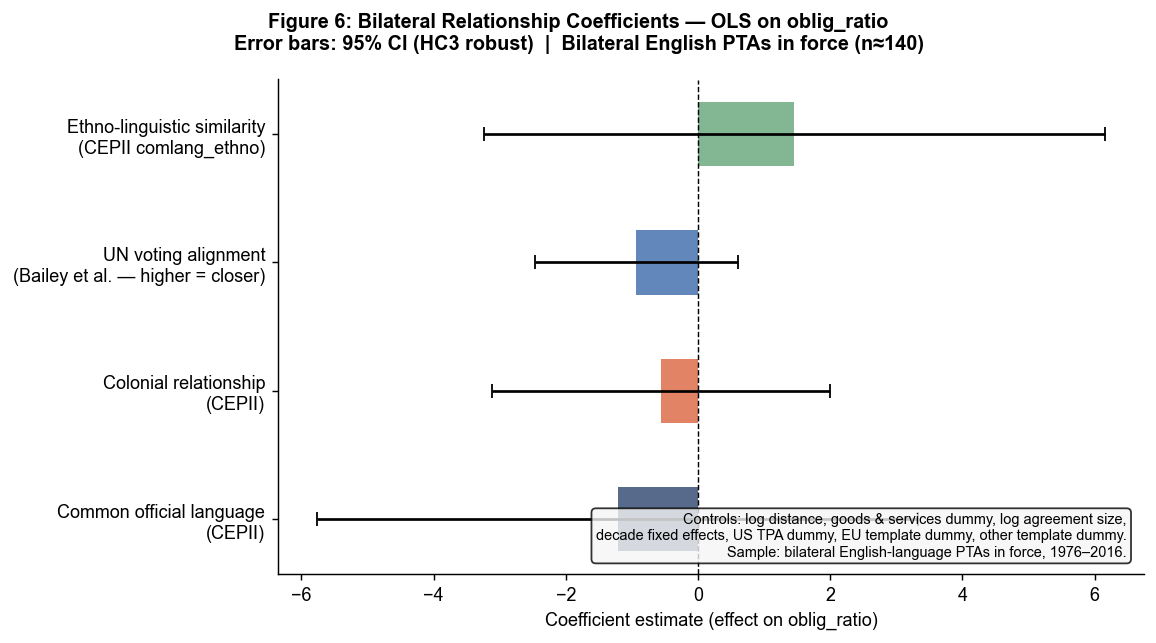

Saved: fig6_coef_plot.png

RESULT INTERPRETATION

Common official language (CEPII comlang_off)
  Estimate: -1.2168  (p = 0.600)  → NEGATIVE ↓
  POSITIVE → rational design: shared language enables precise binding drafting.
  NEGATIVE → trust-substitution: shared language = informal trust,
  reducing need for formal legal hardness.

Colonial relationship (CEPII colony)
  Estimate: -0.5585  (p = 0.669)  → NEGATIVE ↓
  Former colonial ties often reflect shared common-law drafting traditions,
  which tend toward shall-based obligation language. A positive coefficient
  may reflect drafting convention as much as trust or rational design.

UN voting alignment — higher = more aligned (Bailey et al.)
  Estimate: -0.9320  (p = 0.235)  → NEGATIVE ↓
  POSITIVE → rational design: politically close pairs commit to hard obligations
  because the relationship gives confidence of compliance.
  NEGATIVE → trust-substitution: aligned pairs signal solidarity softly.

Ethno-linguistic similarity (CEPII com

In [72]:
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# ── Variable preparation ──────────────────────────────────────────────────────
df_reg = df_analysis.copy()
df_reg['log_words'] = np.log(df_reg['total_words'].replace(0, np.nan))
df_reg['year_int']  = pd.to_numeric(df_reg['year_int'], errors='coerce')

for col in ['d_us_tpa','d_eu_template','d_other_template',
            'd_eastern_european','d_central_asian']:
    if col in df_reg.columns:
        df_reg[col] = pd.to_numeric(df_reg[col], errors='coerce').fillna(0)
    else:
        df_reg[col] = 0

# ── Variable sets ─────────────────────────────────────────────────────────────
# ip_similarity is always included — when Bailey is missing it will be all-NaN
# and those rows are dropped by dropna below (reduces N with a printed warning).
DYADIC_VARS = [v for v in ['comlang_off','colony','ip_similarity','comleg_ethno']
               if v in df_reg.columns]

for _v in DYADIC_VARS.copy():
    _n = df_reg[_v].notna().sum()
    if _n == 0:
        print(f"⚠  '{_v}' is all-NaN — file not loaded. Excluded from regression.")
        DYADIC_VARS = [v for v in DYADIC_VARS if v != _v]
    else:
        print(f"   '{_v}': {_n}/{len(df_reg)} non-null  (mean={df_reg[_v].mean():.3f})")

CONTROLS = [c for c in ['log_dist','goods_services','log_words',
                         'C(decade)',
                         'd_us_tpa','d_eu_template','d_other_template']
            if c in df_reg.columns or c == 'C(decade)']

ALL_VARS     = DYADIC_VARS + CONTROLS
formula_main = 'oblig_ratio ~ ' + ' + '.join(ALL_VARS)

df_reg_clean = df_reg.dropna(subset=['oblig_ratio','log_dist','log_words'] + DYADIC_VARS)
print(f"Observations in main regression: {len(df_reg_clean)} / {len(df_reg)}")

# ── Main OLS ──────────────────────────────────────────────────────────────────
model_main = smf.ols(formula_main, data=df_reg_clean).fit(cov_type='HC3')

print("\n" + "=" * 65)
print("MAIN REGRESSION — OLS with HC3 robust standard errors")
print(f"DV: oblig_ratio  |  N = {int(model_main.nobs)}")
print(f"Controls: log_dist, goods_services, log_words, decade FE,")
print(f"          d_us_tpa, d_eu_template, d_other_template")
print("=" * 65)
print(model_main.summary2().tables[1].round(4).to_string())
print(f"\nR² = {model_main.rsquared:.3f}  |  Adj. R² = {model_main.rsquared_adj:.3f}")

# ── Robustness checks ─────────────────────────────────────────────────────────
def stars(p):
    if pd.isna(p): return ''
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''

# R1: Non-template only
df_notmpl = df_reg_clean[(df_reg_clean['d_us_tpa'] + df_reg_clean['d_eu_template']) == 0].copy()
model_r1  = smf.ols(formula_main, data=df_notmpl).fit(cov_type='HC3') \
            if len(df_notmpl) >= 10 else None
print(f"\nR1 (no-template) : N = {len(df_notmpl)}")

# R2: Linear year trend instead of decade FE
formula_r2 = formula_main.replace('C(decade)','year_int')
model_r2   = smf.ols(formula_r2, data=df_reg_clean).fit(cov_type='HC3')
print(f"R2 (linear trend): N = {int(model_r2.nobs)}")

# R3: oblig_ratio_core as DV
model_r3 = None
if 'oblig_ratio_core' in df_reg_clean.columns:
    df_core    = df_reg_clean.dropna(subset=['oblig_ratio_core'])
    formula_r3 = formula_main.replace('oblig_ratio','oblig_ratio_core')
    model_r3   = smf.ols(formula_r3, data=df_core).fit(cov_type='HC3') \
                 if len(df_core) >= 10 else None
    print(f"R3 (core DV)     : N = {len(df_core)}")

# ── Robustness summary table ──────────────────────────────────────────────────
rows = []
for var in DYADIC_VARS:
    row = {'Variable': var}
    for label, model in [('Main', model_main), ('No Template', model_r1),
                         ('Linear Trend', model_r2), ('Core DV', model_r3)]:
        if model is not None and var in model.params.index:
            c, p = model.params[var], model.pvalues[var]
            row[label] = f'{c:.4f}{stars(p)}'
        else:
            row[label] = '—'
    rows.append(row)

tbl = pd.DataFrame(rows)
print("\n" + "=" * 65)
print("ROBUSTNESS SUMMARY — Dyadic Variable Coefficients")
print("* p<.10  ** p<.05  *** p<.01  (HC3 robust standard errors)")
print("=" * 65)
print(tbl.to_string(index=False))
print(f"N: Main={int(model_main.nobs)} | No-Template={len(df_notmpl)} | LinearTrend={int(model_r2.nobs)}")

# ── Coefficient plot (Figure 6) ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle(
    'Figure 6: Bilateral Relationship Coefficients — OLS on oblig_ratio\n'
    'Error bars: 95% CI (HC3 robust)  |  Bilateral English PTAs in force (n≈140)',
    fontsize=11, fontweight='bold'
)

VAR_LABELS = {
    'comlang_off'   : 'Common official language\n(CEPII)',
    'colony'        : 'Colonial relationship\n(CEPII)',
    'ip_similarity' : 'UN voting alignment\n(Bailey et al. — higher = closer)',
    'comleg_ethno'  : 'Ethno-linguistic similarity\n(CEPII comlang_ethno)',
}
COLORS = ['#1F3864','#D85A30','#2E5FA3','#5A9E6F']

plot_vars = [v for v in DYADIC_VARS if v in model_main.params.index]
for i, var in enumerate(plot_vars):
    coef = model_main.params[var]
    ci   = model_main.conf_int(alpha=0.05).loc[var]
    pval = model_main.pvalues[var]

    ax.barh(i, coef, color=COLORS[i % len(COLORS)], alpha=0.75, height=0.5)
    ax.errorbar(coef, i,
                xerr=[[coef - ci[0]], [ci[1] - coef]],
                fmt='none', color='black', capsize=4, linewidth=1.5)
    sig = stars(pval)
    if sig:
        ax.text(ci[1] + 0.003, i, sig, va='center', fontsize=11, fontweight='bold')

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(range(len(plot_vars)))
ax.set_yticklabels([VAR_LABELS.get(v, v) for v in plot_vars], fontsize=10)
ax.set_xlabel('Coefficient estimate (effect on oblig_ratio)', fontsize=10)
ax.spines[['top','right']].set_visible(False)

note = ("Controls: log distance, goods & services dummy, log agreement size,\n"
        "decade fixed effects, US TPA dummy, EU template dummy, other template dummy.\n"
        "Sample: bilateral English-language PTAs in force, 1976–2016.")
ax.text(0.98, 0.03, note, transform=ax.transAxes, fontsize=8,
        va='bottom', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#F5F5F5', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig6_coef_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig6_coef_plot.png")

# ── Interpretation ────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("RESULT INTERPRETATION")
print("=" * 65)

interp = {
    'comlang_off': (
        "Common official language (CEPII comlang_off)",
        "POSITIVE → rational design: shared language enables precise binding drafting.\n"
        "  NEGATIVE → trust-substitution: shared language = informal trust,\n"
        "  reducing need for formal legal hardness."
    ),
    'colony': (
        "Colonial relationship (CEPII colony)",
        "Former colonial ties often reflect shared common-law drafting traditions,\n"
        "  which tend toward shall-based obligation language. A positive coefficient\n"
        "  may reflect drafting convention as much as trust or rational design."
    ),
    'ip_similarity': (
        "UN voting alignment — higher = more aligned (Bailey et al.)",
        "POSITIVE → rational design: politically close pairs commit to hard obligations\n"
        "  because the relationship gives confidence of compliance.\n"
        "  NEGATIVE → trust-substitution: aligned pairs signal solidarity softly."
    ),
    'comleg_ethno': (
        "Ethno-linguistic similarity (CEPII comlang_ethno — NOT legal-family origin)",
        "Captures shared ethno-linguistic background. Positive = shared cultural context\n"
        "  predicts harder drafting. Partially overlaps with comlang_off — interpret with caution."
    ),
}

for var in DYADIC_VARS:
    if var not in model_main.params.index or var not in interp:
        continue
    name, text = interp[var]
    coef = model_main.params[var]
    pval = model_main.pvalues[var]
    direction = 'POSITIVE ↑' if coef > 0 else 'NEGATIVE ↓'
    print(f"\n{name}")
    print(f"  Estimate: {coef:.4f}{stars(pval)}  (p = {pval:.3f})  → {direction}")
    print(f"  {text}")

if 'd_us_tpa' in model_main.params:
    c = model_main.params['d_us_tpa']
    p = model_main.pvalues['d_us_tpa']
    print(f"\nUS TPA template (d_us_tpa)")
    print(f"  Estimate: {c:.4f}{stars(p)}  (p = {p:.3f})")
    print("  Expected POSITIVE & significant — US TPA is hard by construction.")
    print("  Absorbs template variation so dyadic coefficients reflect organic negotiation.")

print(f"\nR² = {model_main.rsquared:.3f}  |  Adj. R² = {model_main.rsquared_adj:.3f}")
print(f"N   = {int(model_main.nobs)}  (bilateral English PTAs in force, 1976–2016)")
print("\nNote: comleg_ethno = CEPII comlang_ethno (ethno-linguistic similarity),")
print("not legal-family origin (La Porta et al. 2008). Interpret accordingly.")


---
## Part 18: Save Outputs

In [ ]:
# ── Save all outputs ──────────────────────────────────────────────────────────

# 1. Agreement-level analysis table (primary regression input)
df_agreement.to_csv(os.path.join(OUTPUT_DIR, 'agreement_scores_v5.csv'), index=False)
print("Saved: agreement_scores_v5.csv")

# 2. Agreement metadata with asymmetry flags
df_meta.to_csv(os.path.join(OUTPUT_DIR, 'tota_metadata_v5.csv'), index=False)
print("Saved: tota_metadata_v5.csv")

# 3. Dyadic analysis table (bilateral sample + all merged variables)
if 'df_analysis' in dir():
    df_analysis.to_csv(os.path.join(OUTPUT_DIR, 'dyadic_analysis_v5.csv'), index=False)
    print("Saved: dyadic_analysis_v5.csv")

# 4. Article-level corpus with all scores
save_cols = [
    'pta_id','agreement_name','year',
    'chapter_name','chapter_norm','chapter_index',
    'article_number','article_name','word_count',
    'hard_raw','hard_p1k','soft_raw','soft_p1k',
    'mixed_raw','mixed_p1k','enf_raw','enf_p1k',
    'soft_total','oblig_ratio',
]
save_cols = [c for c in save_cols if c in df_articles.columns]
df_articles[save_cols].to_csv(
    os.path.join(OUTPUT_DIR, 'corpus_articles_v5.csv'), index=False)
print("Saved: corpus_articles_v5.csv")

print(f"\nAll outputs saved to: {OUTPUT_DIR}")
print("\n" + "=" * 55)
print("FILES NEEDED TO RUN PARTS 16–17")
print("=" * 55)
print("  dist_cepii.dta          → CEPII GeoDist (already uploaded)")
print("  IdealpointsJuly2025.tab → Bailey et al. (Harvard Dataverse)")
print("    https://dataverse.harvard.edu/dataset.xhtml?persistentId=hdl:1902.1/12379")


Saved: agreement_scores_v4.csv
Saved: tota_metadata_v4.csv
Saved: corpus_articles_v4.csv

All outputs saved to: rta_texts

NEXT STEPS
  1. Run with max_ptas=None for full 423 English PTA corpus
  2. Place Hofmann et al. CSV in working directory (Part 15)
  3. Place CEPII GeoDist CSV in working directory (Part 16)
  4. Place Bailey et al. TAB file in working directory (Part 16)
  5. Complete dyadic merge and run regression (Part 17)
